# Preparación de datos - G6

In [61]:
# Liberias
import pandas as pd
import numpy as np
from unidecode import unidecode
from datetime import date
import rasterio
pd.set_option('display.max_columns', None)


#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

# librerias de modelado para regresion, lasso, ridge y elastic net
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

## 1. Base de datos principal

- Casos confirmados de Dengue y Dengue grave mensual 2007 a 2024 agregado por municipio de residencia, obtenida del SISPRO del ministerio de salud.
- Codigo divipola y coordenadas obtenidas de datos del DANE
https://www.datos.gov.co/Mapas-Nacionales/DIVIPOLA-C-digos-municipios-geolocalizados/vafm-j2df/about_data
- Datos climaticos mesnuales de temperatura y precipitación obtenidos de archivos historicos de WorldClim
https://www.worldclim.org/data/monthlywth.html


En esta primera sección se realiza la lectura y preparación inicial de las fuentes de datos, a continuación se lee la base de datos extraida del Sistema de Información de Salud y Protección social (SISPRO), estos datos son de consulta pública con usuario y contienen el consolidado de casos de Dengue y Dengue Grave para el aplicativo propuesto

In [62]:
####################### PARAMETRO PINCIPAL #######################
#* Se escoge que tipo de casos se va a usar para el análisis, si casos confirmados por lugar 
#* de residencia o casos confirmados por lugar de ocurrencia
#! Cambia a 'ocur' si se va a usar casos confirmados en lugar de ocurrencias
#! 'res' para casos confirmado por lugar de residencia
hoja_start = 'ocur'

In [63]:
import pandas as pd
import numpy as np
import rasterio
from unidecode import unidecode
import calendar
from pathlib import Path

def normalize_str(s):
    """Utility to clean and normalize strings."""
    if not isinstance(s, str):
        return s
    return unidecode(str(s).split('-')[-1].strip().lower())

def load_db(f_path, sheet_name):
    """
    Carga y preprocesa los datos de dengue desde un archivo Excel.
    """
    # Usar converter para evitar problemas de tipos en columnas conocidas
    df = pd.read_excel(f_path, sheet_name=sheet_name)
    print(f"Original shape: {df.shape}")
    print(f"Original columns: {df.columns.tolist()}")
    print(f'Original info:\n{df.info()}')
    df.fillna(0, inplace=True)  # Rellenar NaN con 0 para evitar problemas en el melt
    # 1. Clean column names
    df.columns = [normalize_str(c) for c in df.columns]
    df.rename(columns={'ano epidemiologico': 'year'}, inplace=True)

    # 2. Filter and Normalize strings
    df = df[~df['municipio'].str.contains('Sin Informacion', na=False)]
    df = df[df['pais'] != 'no definido']
    
    cols_to_fix = ['pais', 'departamento', 'municipio']
    for col in cols_to_fix:
        df[col] = df[col].apply(normalize_str)

    # 3. Reshape (Melt)
    df = df.melt(
        id_vars=['pais', 'departamento', 'municipio', 'year'],
        var_name='mes',
        value_name='casosconfirmados'
    )

    # 4. Map Months using standard library
    # Creates a map: {'Enero': 1, ...} assuming names are in Spanish as in the snippet
    month_names = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 
                   'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']
    mes_mapping = {name: i+1 for i, name in enumerate(month_names)}
    
    df['mes'] = df['mes'].map(mes_mapping)
    
    return df

def fill_location_timeseries(df):
    """
    Completa la serie temporal para cada combinación de Departamento y Municipio,
    asegurando que el rango de fechas sea específico para el inicio y fin 
    de cada ubicación (departamento-municipio).
    """
    # 1. Asegurar que exista la columna 'date'
    if 'date' not in df.columns:
        df['date'] = pd.to_datetime(pd.DataFrame({
            'year': df['year'],
            'month': df['mes'],
            'day': 1
        }))
    
    # 2. Definir las columnas que identifican la ubicación
    location_cols = ['departamento', 'municipio']
    
    # 3. Agrupar por ubicación y aplicar resample
    # El método resample('MS') (Month Start) dentro de un groupby
    # crea automáticamente el rango desde la fecha mínima a la máxima de CADA grupo.
    df_complete = (
        df.set_index('date')
        .groupby(location_cols)
        .resample('MS')
        .asfreq()  # Inserta filas con NaN para las fechas faltantes
        .drop(columns=location_cols, errors='ignore') # Eliminamos las columnas para que no se dupliquen al resetear index
        .reset_index()
    )
    
    # 4. Restaurar los valores de Year y Month para las nuevas filas
    df_complete['year'] = df_complete['date'].dt.year
    df_complete['mes'] = df_complete['date'].dt.month
    
    # Nota: 'casosconfirmados' y cualquier otra variable 
    # quedarán como NaN automáticamente en los huecos internos.
    
    return df_complete.sort_values(location_cols + ['date']).reset_index(drop=True)

def add_worldclim(df: pd.DataFrame,
                  path_divipola: str = 'data/Listados_DIVIPOLA.xlsx',
                  sheet_divipola: str = 'Municipios',
                  elevation_files: dict = None,
                  climate_folders: dict = None):
    
    if elevation_files is None:
        elevation_files = {'elevacion': Path('data/worldclim/wc2.1_2.5m_elev/wc2.1_2.5m_elev.tif')}
    if climate_folders is None:
        climate_folders = {
            'tmin': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2020-2024')],
            'tmax': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2020-2024')],
            'prec': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2020-2024')]
        }

    # 1. Load and Clean DIVIPOLA
    divipola = pd.read_excel(path_divipola, sheet_name=sheet_divipola, skiprows=10, skipfooter=10)
    divipola.columns = ['cod_dept', 'departamento', 'cod_muni', 'municipio', 'tipo', 'longitud', 'latitud', 'nota']
    divipola = divipola[['departamento', 'municipio', 'cod_muni', 'tipo', 'longitud', 'latitud']]
    
    for col in ['departamento', 'municipio']:
        divipola[col] = divipola[col].apply(normalize_str)

    # 2. Municipality Name Harmonization (optimized via mapping)
    renamer = {
        'putumayo': {'leguizamo': 'puerto leguizamo'},
        'cauca': {'sotara': 'sotara paispamba', 'piendamo': 'piendamo - tunia', 'lopez': 'lopez de micay'},
        'valle del cauca': {'cali': 'santiago de cali'},
        # ... (rest of your mapping)
    }
    
    for dept, muni_map in renamer.items():
        mask = df['departamento'] == dept
        df.loc[mask, 'municipio'] = df.loc[mask, 'municipio'].replace(muni_map)

    # 3. Filter only valid locations
    df['loc_key'] = df['departamento'] + "_" + df['municipio']
    divipola['loc_key'] = divipola['departamento'] + "_" + divipola['municipio']
    
    df = df[df['loc_key'].isin(divipola['loc_key'])]
    df = df.merge(divipola.drop(columns=['departamento', 'municipio']), on='loc_key', how='left')

    # 4. Extract Elevation (Rasterio)
    unique_locs = df[['loc_key', 'longitud', 'latitud']].drop_duplicates()
    coords = list(zip(unique_locs['longitud'], unique_locs['latitud']))
    
    for var, path in elevation_files.items():
        with rasterio.open(path) as src:
            unique_locs[var] = [val[0] for val in src.sample(coords)]
            
    df = df.merge(unique_locs[['loc_key', 'elevacion']], on='loc_key', how='left')

    # 5. Extract Climate Data (Optimized: Open file once per group)
    climate_results = []
    
    # Prepare month strings for file naming
    df['mes_str'] = df['mes'].apply(lambda x: f"{int(x):02d}")
    
    groups = df.groupby(['year', 'mes_str'])
    for (year, month_str), group_df in groups:
        idx = 0 if year <= 2009 else (1 if year <= 2019 else 2)
        
        group_coords = list(zip(group_df['longitud'], group_df['latitud']))
        
        for var, folders in climate_folders.items():
            folder = folders[idx]
            # Assumes file structure based on your snippet logic
            file_name = f"{folder.name.rsplit('_', 1)[0]}_{year}-{month_str}.tif"
            file_path = folder / file_name
            
            if file_path.exists():
                with rasterio.open(file_path) as src:
                    values = [val[0] for val in src.sample(group_coords)]
                    for i, val in enumerate(values):
                        climate_results.append({
                            'loc_key': group_df.iloc[i]['loc_key'],
                            'year': year,
                            'mes': group_df.iloc[i]['mes'],
                            'variable': var,
                            'valor': val
                        })

    # 6. Pivot and Final Merge
    res_df = pd.DataFrame(climate_results)
    res_df = res_df.pivot_table(index=['loc_key', 'year', 'mes'], columns='variable', values='valor').reset_index()
    
    final_df = df.merge(res_df, on=['loc_key', 'year', 'mes'], how='left')
    final_df.rename(columns={'prec': 'Precipitacion', 'tmax': 'TempMax', 'tmin': 'TempMin'}, inplace=True)
    
    # Cleanup and Save
    final_df.drop(columns=['loc_key', 'mes_str'], inplace=True)
    
    return final_df



En la fase inicial, se identifica que los registros de SIVIGILA pueden presentar discontinuidades temporales o falta de reportes en meses específicos para ciertos municipios. Para resolver esto, la función load_db transforma los datos de un formato ancho (meses como columnas) a uno "largo" o tidy data, eliminando registros sin información. Posteriormente, mediante la función fill_location_timeseries, se genera una serie de tiempo continua para cada locación. Este proceso asegura que cada combinación de Departamento y Municipio cuente con una fila por cada mes dentro de su rango histórico, estandarizando las fechas al primer día de cada mes para facilitar el análisis posterior.

Para la georreferenciación, se integra la base de datos de la codificación DIVIPOLA del DANE. Esta fuente provee las coordenadas geográficas (latitud y longitud), el código oficial del municipio y su clasificación (municipio, isla o área no municipalizada). Estas variables son fundamentales para el reconocimiento espacial y la posterior vinculación de datos satelitales.

Sin embargo, para lograr una unión (merge) exitosa, es imperativo normalizar los nombres de las locaciones. Dado que los sistemas SIVIGILA y DANE suelen tener discrepancias ortográficas, se aplica un proceso de limpieza que incluye la conversión a minúsculas, la eliminación de caracteres especiales y acentos (mediante unidecode), y el uso de un diccionario de homologación (renamer). Este diccionario corrige nombres específicos (por ejemplo, transformando "Cali" en "Santiago de Cali" o "Leguizamo" en "Puerto Leguizamo") para garantizar la integridad referencial entre ambas fuentes.

Finalmente, se procede al enriquecimiento ambiental mediante el procesamiento de archivos ráster con la librería rasterio. En primer lugar, se extrae la elevación exacta de cada municipio basándose en sus coordenadas. Luego, se integran las variables climáticas de WorldClim (precipitación, temperatura máxima y mínima). Este paso es dinámico y preciso: el sistema identifica el archivo histórico correspondiente a cada registro según su año y mes, extrayendo los valores climáticos específicos para ese punto geográfico. El resultado final es una base de datos robusta, con continuidad temporal y variables biofísicas listas para modelos de predicción.

In [64]:

df = load_db('data/Base_deng.xlsx', sheet_name=hoja_start)

df = fill_location_timeseries(df)

df = add_worldclim(df)

df.head()

df.to_csv(f'data/dengue_data_v2_{hoja_start}.csv', index=False, sep='|')


Original shape: (14684, 16)
Original columns: ['País', 'Departamento', 'Municipio', 'Año Epidemiologico', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
<class 'pandas.DataFrame'>
RangeIndex: 14684 entries, 0 to 14683
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   País                14684 non-null  str    
 1   Departamento        14684 non-null  str    
 2   Municipio           14684 non-null  str    
 3   Año Epidemiologico  14684 non-null  int64  
 4   Enero               8507 non-null   float64
 5   Febrero             7816 non-null   float64
 6   Marzo               7786 non-null   float64
 7   Abril               7895 non-null   float64
 8   Mayo                8097 non-null   float64
 9   Junio               8251 non-null   float64
 10  Julio               8444 non-null   float64
 11  Agosto              8083 non-

In [65]:
df = pd.read_csv(f'data/dengue_data_v2_{hoja_start}.csv', sep='|')
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202171,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0
202172,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0
202173,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0
202174,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0


### 1.1. Datos de fenomeno del niño y la niña (añadidos a base principal)

Se agregan datos del fenomeno del niño y de la niña con marcación categorica, este tipo de variable se debe agregar con rezagos temporales para la base definitiva, ya que la presencia continua de temeperaturas aumentadas o disminuidas son precisamente las que denotan que el fenomeno se acentue y se haga mención de su impacto a nivel nacional.

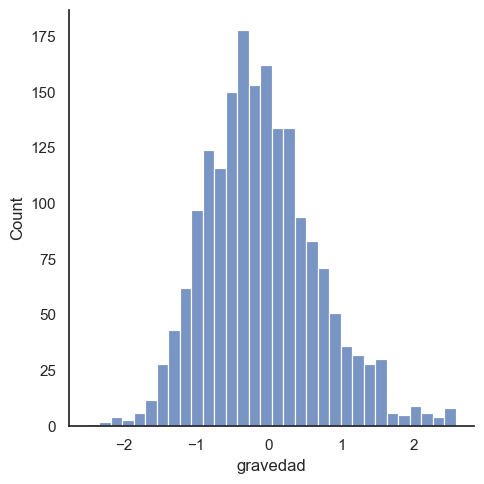

In [66]:
df_nino = pd.read_csv('data/nino34.long.anom.csv')
#* cambio en nobmres de columnas
df_nino.columns = ['date', 'gravedad']
#* se reemplazo el -99.99 por pd.na ya que es el dato faltante
df_nino['fenomeno'] = df_nino['gravedad'].apply(lambda x: pd.na if x==-99.99 else x)
#* agregar marcacion de la gravedad, si es >=1.5 nino_sev, 1.5>x>=0.5 es nino_moderado
df_nino['fenomeno'] = df_nino['gravedad'].apply(lambda x: 'nino_sev' if x >= 1.5 else
                                                          'nino_mod' if 1.5>x>=0.5 else
                                                          'neutral' if 0.5 > x >-0.5 else
                                                          'nina_mod' if -1.5<x<=-0.5 else
                                                          'nina_sev')

sns.displot(df_nino, x="gravedad")
df_nino.drop(columns='gravedad', inplace=True)


#* merge df and df_nino on date
df = df.merge(df_nino, on='date', how='left')

df.to_csv(f'data/dengue_data_v2_{hoja_start}.csv', index=False, sep='|')

### 1.2. Datos de trafico vehicular (guardados para uso posterior)

Se revisa la base de datos de trafico vehicular, particularmente se obtinene los datos relativos a trafico en peajes a lo largo del territorio nacional, los peajes manejas un id y un nombre especifios y tienen datos en ventanas de tiempo no homogeneas, se registra el trafico en un peaje particular para una ventana de 10 días en un mes y se pueden presentar otras ventanas en el mismo mes para el mismo peaje, parte del tratamiento de los datos invluye suavizar los datos de estas ventans a segmentos de datos diarios con el valor promedio del trafico para esos días, a partir de los valores diarios se obtiene el dato mensual de manera ordenada y teniendo en cuenta todo el trafico del peaje.

In [67]:
df_trafico = pd.read_csv('data/Tráfico_Vehicular_ANI_20260411.csv')
df_trafico['Peaje'] = df_trafico['Peaje'].apply(lambda x: unidecode(str(x).lower().strip()))
df_trafico.drop(columns=[i for i in df_trafico.columns if i not in ['Peaje','CantidadTrafico', 'CantidadExentos787', 'Desde','Hasta']], inplace=True)
df_trafico['CantidadTrafico'] = df_trafico['CantidadTrafico'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_trafico['CantidadExentos787'] = df_trafico['CantidadExentos787'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_trafico['TraficoTotal'] = df_trafico['CantidadTrafico'].astype(float) + df_trafico['CantidadExentos787'].astype(float)
df_trafico.drop(columns='CantidadTrafico', inplace=True)
df_trafico.drop(columns='CantidadExentos787', inplace=True)

df_trafico.head()


df_trafico['Desde'] = pd.to_datetime(df_trafico['Desde'], errors='coerce')
df_trafico['Hasta'] = pd.to_datetime(df_trafico['Hasta'], errors='coerce')

df_trafico['Desde'].min(), df_trafico['Hasta'].max()
# 2. Calculate the total days in each span (+1 to make it inclusive of start and end dates)
df_trafico['Dias'] = (df_trafico['Hasta'] - df_trafico['Desde']).dt.days + 1

# 3. Calculate the daily traffic for each specific row
df_trafico['TraficoDiario'] = df_trafico['TraficoTotal'] / df_trafico['Dias']

# 4. Generate a list of all individual dates between 'Desde' and 'Hasta' for each row
df_trafico['Fecha'] = df_trafico.apply(lambda row: pd.date_range(row['Desde'], row['Hasta']), axis=1)

# 5. Explode the DataFrame so every single day gets its own row with its 'TraficoDiario'
df_exploded = df_trafico.explode('Fecha')

# 6. Extract just the Year and Month from the exploded daily dates to group by
df_exploded['Mes_Anio'] = df_exploded['Fecha'].dt.to_period('M')

# 7. Group by 'Peaje' and the new 'Mes_Anio', summing up the daily traffic
df_monthly = df_exploded.groupby(['Peaje', 'Mes_Anio'])['TraficoDiario'].sum().reset_index()

# 8. Rename the aggregated column back to something meaningful
df_monthly.rename(columns={'TraficoDiario': 'TraficoTotalMensual'}, inplace=True)
meta_d_peajes = pd.read_csv('data/Peajes_.csv')
meta_d_peajes['nombrepeaje'] = meta_d_peajes['nombrepeaje'].apply(lambda x: unidecode(str(x).lower().strip()))

# * https://www.colombiaenmapas.gov.co/?u=0&t=19&servicio=100

from thefuzz import process, fuzz


def get_fuzzy_mapping(df_left, df_right, left_col, right_col, threshold=80):
    """
    Finds the best match from df_right for each entry in df_left.
    """
    # Get unique names from the right dataframe to speed up processing
    unique_right = df_right[right_col].unique()
    
    # Define a helper to find the best match
    def find_match(x):
        # process.extractOne returns (match, score)
        match, score = process.extractOne(x, unique_right, scorer=fuzz.token_sort_ratio)
        return match if score >= threshold else None

    def find_score(x):
        match, score = process.extractOne(x, unique_right, scorer=fuzz.token_sort_ratio)
        return score

    # Create mapping columns
    df_left['best_match'] = df_left[left_col].apply(find_match)
    df_left['similarity_score'] = df_left[left_col].apply(find_score)
    
    return df_left

# Execute mapping
mapped_df = get_fuzzy_mapping(df_trafico, meta_d_peajes, 'Peaje', 'nombrepeaje')

print("Mapping Results:")
print(set(list(zip(mapped_df['Peaje'], mapped_df['best_match'], mapped_df['similarity_score']))))


#* updating names in meta_d_peajes to match with df_trafico
matches = dict(zip(mapped_df['Peaje'], mapped_df['best_match']))
meta_d_peajes['nombrepeaje'] = meta_d_peajes['nombrepeaje'].replace(matches)

meta_d_peajes.drop(columns=[i for i in meta_d_peajes.columns if i not in ['nombrepeaje', 'X', 'Y']], inplace=True)
meta_d_peajes.rename(columns={'nombrepeaje': 'Peaje', 'X':'longitud','Y':'latitud'}, inplace=True)

df_monthly = df_monthly.merge(meta_d_peajes, on='Peaje', how='left')
df_monthly.head()

df_monthly.to_csv('data/df_monthly_trafico_peajes.csv', index=False, sep='|')

C:\Users\sergi\AppData\Local\Temp\ipykernel_20248\385718182.py:1: DtypeWarning: Columns (0: CantidadTrafico) have mixed types. Specify dtype option on import or set low_memory=False.
  df_trafico = pd.read_csv('data/Tráfico_Vehicular_ANI_20260411.csv')
C:\Users\sergi\AppData\Local\Temp\ipykernel_20248\385718182.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_trafico['Desde'] = pd.to_datetime(df_trafico['Desde'], errors='coerce')
C:\Users\sergi\AppData\Local\Temp\ipykernel_20248\385718182.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_trafico['Hasta'] = pd.to_datetime(df_trafico['Hasta'], errors='coerce')


Mapping Results:
{('puerto berrio', 'puerto berrio', 100), ('morrison', 'morrison', 100), ('paraguachon', 'paraguachon', 100), ('estambul', 'estambul', 100), ('la lizama', 'la lizama', 100), ('supia', 'supia', 100), ('altamira', 'altamira', 100), ('cirilo', 'cirilo', 100), ('platanal', 'platanal', 100), ('aburra', 'aburra', 100), ('tunia', nan, 77), ('rozo', 'rozo', 100), ('el ebanal', 'el ebanal', 100), ('vegachi', nan, 57), ('rio bogota', 'rio bogota', 100), ('mata de cana', 'mata de cana', 100), ('yucao', 'yucao', 100), ('san pedro', 'san pedro', 100), ('pandequeso', 'pandequeso', 100), ('pavas', nan, 62), ('ancon sur', nan, 63), ('neguanje', 'neguanje', 100), ('el placer', 'el placer', 100), ('palmitas', 'pailitas', 88), ('aguas negras', 'aguas negras', 100), ('las palmas', 'las palmas', 100), ('san bernardo', nan, 67), ('honda', 'honda', 100), ('tucurinca', 'tucunica', 82), ('alto pino', 'alto pino', 100), ('los acacios', 'los acacios', 100), ('cabildo', 'cabildo', 100), ('el pica

In [68]:
# correspondencia peajes - municipios
#* a partir de latitud y longitud, asignar el peaje al municipio más cercano
municipios_presentes = df[['departamento', 'municipio', 'longitud', 'latitud']].drop_duplicates()
peajes_presentes = df_monthly[['Peaje', 'longitud', 'latitud']].drop_duplicates()
peajes_presentes.dropna(inplace=True)

#* funcion para calcular distancia entre dos puntos geograficos
from geopy.distance import geodesic
def find_closest_peaje(muni_row, peajes_df):
    #* return at most a list of 3 peajes 1st is closes in radius of 25km,
    #* 2nd is closest in radius of 50km, 3rd is closest in radius of 100km
    #* if no peaje is found for a radius fill the list wiht a None in that position
    closest_peajes = [None, None, None]
    for _, peaje_row in peajes_df.iterrows():
        distance = geodesic((muni_row['latitud'], muni_row['longitud']), (peaje_row['latitud'], peaje_row['longitud'])).km
        if distance <= 25 and closest_peajes[0] is None:
            closest_peajes[0] = peaje_row['Peaje']
        elif distance <= 50 and closest_peajes[1] is None:
            closest_peajes[1] = peaje_row['Peaje']
        elif distance <= 75 and closest_peajes[2] is None:
            closest_peajes[2] = peaje_row['Peaje']
    return closest_peajes

#* aplicar la funcion a cada municipio
municipios_presentes[['Peaje_25km', 'Peaje_50km', 'Peaje_75km']] = municipios_presentes.apply(lambda row: find_closest_peaje(row, peajes_presentes), axis=1, result_type='expand')

municipios_presentes.head()
    

municipios_presentes.to_csv('data/municipios_con_peajes_cercanos.csv', index=False, sep='|')


In [69]:
municipios_presentes

,departamento,municipio,longitud,latitud,Peaje_25km,Peaje_50km,Peaje_75km
0,amazonas,el encanto,-73.207114,-1.748060,None,None,None
216,amazonas,la chorrera,-72.791889,-1.442617,None,None,None
324,amazonas,la pedrera,-69.585499,-1.320301,None,None,None
540,amazonas,la victoria,-71.223208,0.054936,None,None,None
636,amazonas,leticia,-69.941721,-4.198950,None,None,None
...,...,...,...,...,...,...,...
201144,vaupes,yavarate,-69.203337,0.609142,None,None,None
201312,vichada,cumaribo,-69.795533,4.446352,None,None,None
201528,vichada,la primavera,-70.410515,5.486309,None,None,None
201744,vichada,puerto carreno,-67.487095,6.186636,None,None,None


In [70]:
df_monthly

,Peaje,Mes_Anio,TraficoTotalMensual,longitud,latitud
0,aburra,2020-01,2002.030,-75.651083,6.293192
1,aburra,2020-02,457.408,-75.651083,6.293192
2,aburra,2020-03,741.774,-75.651083,6.293192
3,aburra,2020-04,1560.618,-75.651083,6.293192
4,aburra,2020-05,1126.714,-75.651083,6.293192
...,...,...,...,...,...
15514,zaragoza,2025-02,2796.275,-74.894704,7.633288
15515,zaragoza,2025-03,1323.819,-74.894704,7.633288
15516,zaragoza,2025-04,2075.447,-74.894704,7.633288
15517,zaragoza,2025-05,2247.624,-74.894704,7.633288


In [71]:
municipios_presentes.info()

<class 'pandas.DataFrame'>
Index: 1060 entries, 0 to 201960
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   departamento  1060 non-null   str    
 1   municipio     1060 non-null   str    
 2   longitud      1060 non-null   float64
 3   latitud       1060 non-null   float64
 4   Peaje_25km    465 non-null    object 
 5   Peaje_50km    731 non-null    object 
 6   Peaje_75km    843 non-null    object 
dtypes: float64(2), object(3), str(2)
memory usage: 84.3+ KB


In [72]:
df_monthly['Mes_Anio'].min(), df_monthly['Mes_Anio'].max()

(Period('2014-01', 'M'), Period('2025-06', 'M'))

Aun no se define propiamente el uso de los datos de trafico vehicular ya que la relación del trafico no se conoce de antemano hasta que punto se puede estimar o desestimar por la distancia del peaje a las coordenadas del municipio. Además si la serie de tiempo vien fragmentada es necesario otro ajuste de imputación, sin mencionar que el flujo de trafico es generalizado, lo que es bueno para anticipar el uso de la vía pero no distingue propiamente el sentido del flujo ni si durante el periodo de evaluación este flujo no es simetrico.

### 1.3. Datos sociodemograficos (guardados para uso posterior)

In [73]:
df_pobreza = pd.read_excel('data/anexo_pobreza_monetaria_20_departamento.xls', sheet_name='Gini', skiprows=14, skipfooter=8)
df_pobreza.rename(columns={'Unnamed: 0': 'departamento'}, inplace=True)
df_pobreza.head()
#* La serie más completa es GINI de 2002 a 2020 las demás no tienen 10 años 2012-2020
#* Se propone extrar tendencia y modelarla hasta 2024 para agregar como valor departamental
#* Sin embargo solo tiene 20 departamentos y se recomienda su inclución después de lidiar con los vacios en la base principal
df_pobreza.to_csv('data/pobreza_departamental.csv', index=False, sep='|')

In [74]:
df_pobreza

,departamento,2002,2003,2004,2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Antioquia,0.585,0.589,0.574,0.555,0.580,0.560,0.561,0.537,0.529,0.532,0.555,0.521,0.508,0.496,0.501,0.511,0.530
1,Atlántico,0.530,0.526,0.524,0.507,0.498,0.495,0.496,0.467,0.464,0.453,0.445,0.440,0.432,0.442,0.443,0.454,0.481
2,Bogotá D.C.,0.572,0.547,0.558,0.557,0.533,0.527,0.526,0.522,0.497,0.504,0.502,0.498,0.499,0.498,0.504,0.513,0.559
3,Bolívar,0.533,0.476,0.478,0.482,0.543,0.533,0.514,0.500,0.507,0.501,0.512,0.489,0.480,0.461,0.472,0.479,0.495
4,Boyacá,0.597,0.600,0.555,0.561,0.579,0.538,0.538,0.538,0.532,0.533,0.528,0.536,0.530,0.514,0.483,0.500,0.517
5,Caldas,0.507,0.522,0.521,0.505,0.547,0.541,0.535,0.528,0.522,0.524,0.522,0.512,0.510,0.496,0.490,0.469,0.473
6,Caquetá,0.528,0.508,0.491,0.526,0.487,0.485,0.450,0.459,0.479,0.467,0.472,0.483,0.470,0.457,0.479,0.484,0.468
7,Cauca,0.522,0.474,0.525,0.502,0.596,0.589,0.565,0.554,0.565,0.548,0.535,0.524,0.506,0.504,0.520,0.537,0.515
8,Cesar,0.464,0.439,0.480,0.453,0.545,0.553,0.518,0.506,0.518,0.489,0.473,0.479,0.472,0.487,0.488,0.506,0.524
9,Chocó,0.572,0.562,0.562,0.582,0.619,0.571,0.571,0.567,0.616,0.603,0.598,0.598,0.574,0.566,0.579,0.599,0.560


## 2. Análisis exploratorio de datos

In [75]:
df = pd.read_csv(f'data/dengue_data_v2_{hoja_start}.csv', sep='|')
df.head()

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,391.1,31.0,22.0,nino_mod
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,144.6,32.0,23.0,neutral
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,568.9,30.0,22.0,neutral
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,538.6,30.0,22.0,neutral
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.74806,158,392.1,29.0,22.0,neutral


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 202176 entries, 0 to 202175
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   departamento      202176 non-null  str    
 1   municipio         202176 non-null  str    
 2   date              202176 non-null  str    
 3   pais              168396 non-null  str    
 4   year              202176 non-null  int64  
 5   mes               202176 non-null  int64  
 6   casosconfirmados  168396 non-null  float64
 7   cod_muni          202176 non-null  int64  
 8   tipo              202176 non-null  str    
 9   longitud          202176 non-null  float64
 10  latitud           202176 non-null  float64
 11  elevacion         202176 non-null  int64  
 12  Precipitacion     201780 non-null  float64
 13  TempMax           202176 non-null  float64
 14  TempMin           202176 non-null  float64
 15  fenomeno          202176 non-null  str    
dtypes: float64(6), int64(4), str(6)

In [77]:
#* eliminar filas con nan en columna de precipitacion, tempmax y tempmin
df.dropna(subset=['Precipitacion', 'TempMax', 'TempMin'], inplace=True)

In [78]:
df[[ 'casosconfirmados', 'elevacion', 'Precipitacion', 'TempMax', 'TempMin']].describe()

,casosconfirmados,elevacion,Precipitacion,TempMax,TempMin
count,168012.000000,201780.000000,201780.000000,201780.000000,201780.000000
mean,9.111563,1014.843354,180.366836,28.006170,18.267465
std,60.305616,859.278282,134.807405,4.876679,4.739885
min,0.000000,3.000000,0.100000,9.000000,1.000000
25%,0.000000,153.000000,84.700000,24.000000,15.000000
50%,1.000000,992.000000,155.800000,29.000000,19.000000
75%,4.000000,1690.000000,244.700000,32.000000,23.000000
max,5068.000000,3690.000000,1382.400000,38.000000,28.000000


In [79]:
df[[ 'casosconfirmados', 'elevacion', 'Precipitacion', 'TempMax', 'TempMin']].corr()

,casosconfirmados,elevacion,Precipitacion,TempMax,TempMin
casosconfirmados,1.000000,-0.033779,-0.008337,0.053097,0.044020
elevacion,-0.033779,1.000000,-0.169162,-0.952101,-0.978447
Precipitacion,-0.008337,-0.169162,1.000000,0.026242,0.153772
TempMax,0.053097,-0.952101,0.026242,1.000000,0.947681
TempMin,0.044020,-0.978447,0.153772,0.947681,1.000000


In [80]:
int(df[(df['year']==2024) & (df['mes']==5)]['casosconfirmados'].sum())

37288

In [81]:
# departamentos con mas casos confirmados y porcentaje del total
total_casos = int(df['casosconfirmados'].sum())
df_departamentos = df[['departamento', 'casosconfirmados']].groupby('departamento').sum().reset_index(drop=False)
df_departamentos['casosconfirmados'] = df_departamentos['casosconfirmados'].astype(int)
df_departamentos['Porcentaje'] = (df_departamentos['casosconfirmados'] / total_casos) * 100
depto_list = df_departamentos.sort_values('casosconfirmados', ascending=False)['departamento'].tolist()
df_departamentos.sort_values('casosconfirmados', ascending=False).head(25).reset_index(drop=True)


,departamento,casosconfirmados,Porcentaje
0,valle del cauca,288423,18.840685
1,santander,166643,10.885638
2,tolima,127236,8.311450
3,antioquia,120952,7.900960
4,meta,100458,6.562228
5,huila,93181,6.086872
6,atlantico,79324,5.181690
7,cundinamarca,54945,3.589178
8,cesar,50742,3.314625
9,sucre,43659,2.851941


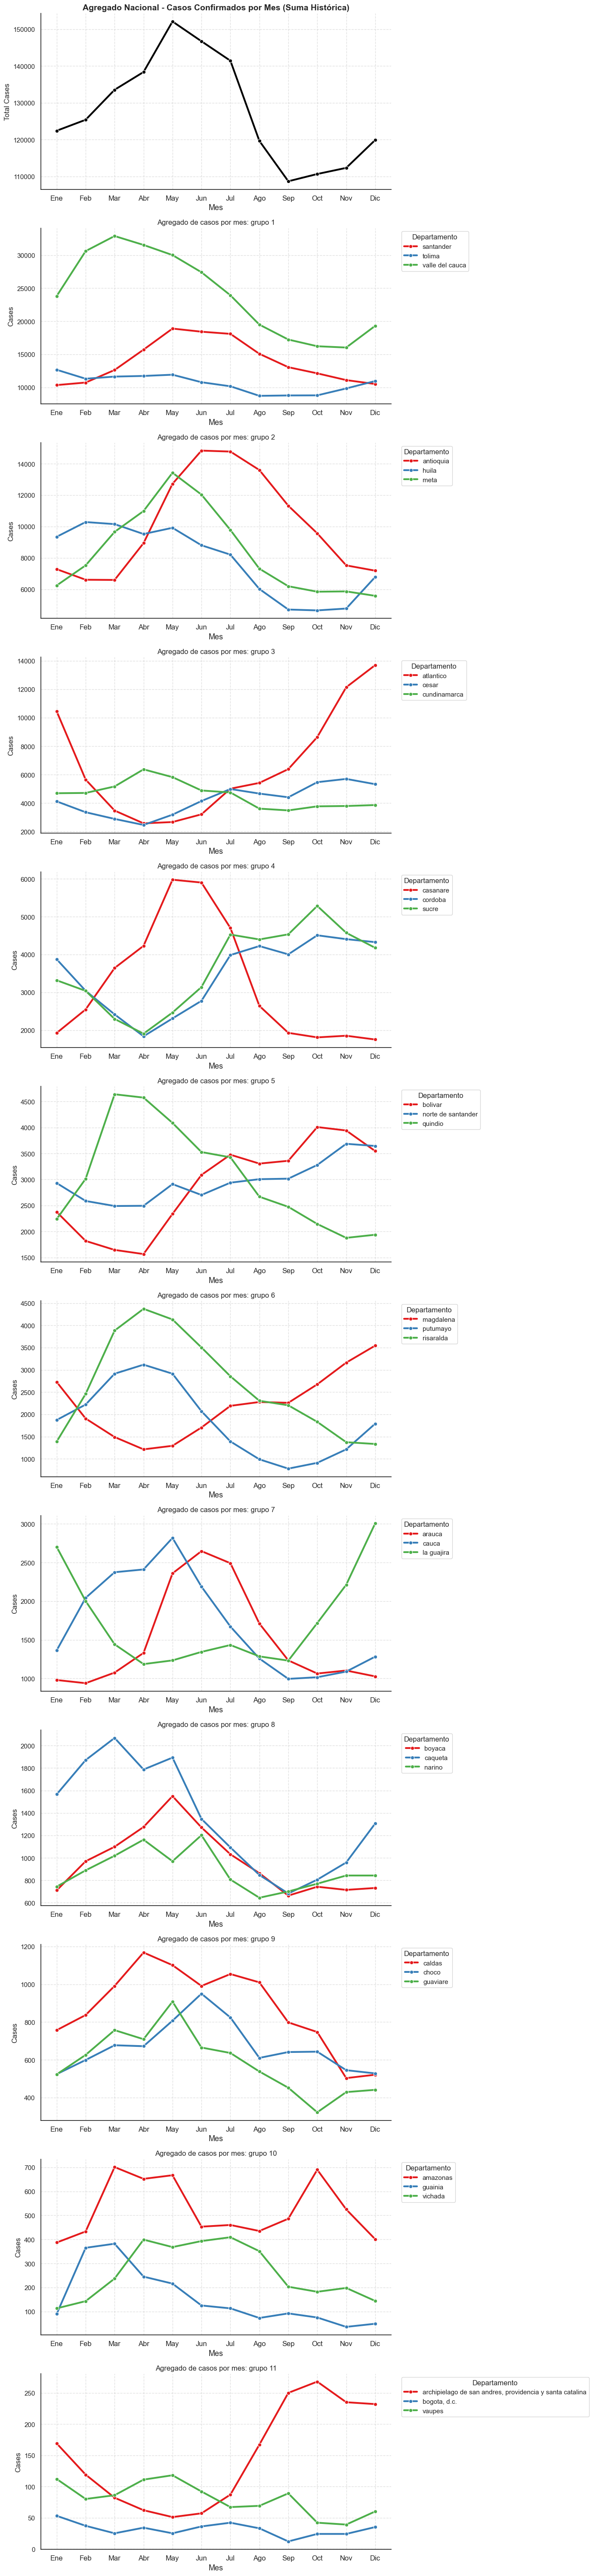

In [82]:
# Assuming 'df' and 'depto_list' are already loaded

df_clean = df.dropna(subset=['casosconfirmados']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['month'] = df_clean['date'].dt.month

national_agg = df_clean.groupby('month')['casosconfirmados'].sum().reset_index()

chunk_size = 3
dept_groups = [depto_list[i:i + chunk_size] for i in range(0, len(depto_list), chunk_size)]

num_plots = 1 + len(dept_groups)

# REMOVED: sharex=True. Now each subplot acts completely independently
fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(14, 5 * num_plots))

if num_plots == 1:
    axes = [axes]

meses_esp = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
custom_palette = "Set1" 

# --- PLOT 1: National Aggregate ---
sns.lineplot(
    data=national_agg, x='month', y='casosconfirmados', 
    ax=axes[0], color='black', linewidth=3, marker='o'
)
axes[0].set_title('Agregado Nacional - Casos Confirmados por Mes (Suma Histórica)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cases')

# --- PLOTS 2+: Department Groups ---
for idx, dept_group in enumerate(dept_groups):
    ax = axes[idx + 1] 
    
    group_data = df_clean[df_clean['departamento'].isin(dept_group)]
    group_agg = group_data.groupby(['month', 'departamento'])['casosconfirmados'].sum().reset_index()
    
    sns.lineplot(
        data=group_agg, x='month', y='casosconfirmados', hue='departamento', 
        ax=ax, linewidth=3, palette=custom_palette, marker='o'
    )
    
    ax.set_title(f'Agregado de casos por mes: grupo {idx + 1}', fontsize=12)
    ax.set_ylabel('Cases')
    ax.legend(title='Departamento', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- APPLY FORMATTING TO ALL PLOTS ---
# Instead of just formatting the bottom_ax, we loop through every single axis
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine(ax=ax)
    
    # Force the 1-12 ticks and apply the Spanish labels to each graph
    ax.set_xticks(range(1, 13))              
    ax.set_xticklabels(meses_esp, fontsize=12) 
    ax.set_xlabel('Mes', fontsize=13)

plt.tight_layout()
plt.show()

In [83]:
#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

In [84]:
# funciones para analisis exploratorio y visualizacion de datos

#* Análisis de correlación
def plot_correlation_map( df ):
    corr = df.corr()
    _ , ax = plt.subplots( figsize =( 12 , 10 ) )
    cmap = sns.diverging_palette( 220 , 10 , as_cmap = True )
    _ = sns.heatmap(
        corr, 
        cmap = cmap,
        square=True, 
        cbar_kws={ 'shrink' : .9 }, 
        ax=ax, 
        annot = True, 
        annot_kws = { 'fontsize' : 12 }
    )

def frecuencia_mensual_con_umbral(df, umbral=5000):
    #* frecuencia por meses y años en cundinamarca con años separados en diferentes subplots
    df_agrupado = df.groupby(['year', 'mes'])['casosconfirmados'].sum().reset_index()
    df_agrupado = df_agrupado.sort_values(by=['year', 'mes'])

    # 2. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 3. Creación de la cuadrícula
    g = sns.FacetGrid(df_agrupado, col="year", col_wrap=4, height=3, aspect=1.5, sharex=False, sharey=False)

    # 4. Gráfico principal (Línea de casos)
    g.map(sns.lineplot, "mes", "casosconfirmados", marker="o")

    # umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label="Umbral 5000")

    # 5. Ajustes finales
    g.set_axis_labels("mes", "Total Casos")
    g.set_titles(col_template="Año {col_name}")
    g.fig.suptitle("Comportamiento Mensual vs Umbral de Referencia", y=1.02)

    g.add_legend()

    plt.show()

def frecuencia_mensual_con_umbral_v2(df, umbral=5000, anos_por_subplot=1):
    """
    Genera gráficos de línea para casos confirmados.
    
    Args:
        df: DataFrame con columnas 'Year', 'Mes', 'CasosConfirmados'.
        umbral: Valor para la línea horizontal de referencia.
        anos_por_subplot: Cantidad de años continuos a mostrar en cada gráfica (ej. 2 para pares de años).
    """
    
    # 1. Agrupación inicial
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    
    # 2. Crear columna 'Fecha' para tener un Eje X continuo
    # Es vital convertir a datetime para que al graficar 2 o 3 años seguidos, 
    # la línea continúe cronológicamente y no se superpongan los meses.
    df_agrupado['Fecha'] = pd.to_datetime(
        df_agrupado['Year'].astype(str) + '-' + df_agrupado['Mes'].astype(str) + '-01'
    )
    df_agrupado = df_agrupado.sort_values('Fecha')

    # 3. Definir los bloques de años (Periodos)
    min_year = df_agrupado['Year'].min()
    
    # Calculamos un índice de bloque: (AñoActual - AñoMinimo) // N
    df_agrupado['Bloque_Indice'] = (df_agrupado['Year'] - min_year) // anos_por_subplot
    
    # Generamos etiquetas legibles para los títulos (Ej: "2007-2008")
    def generar_etiqueta(row):
        inicio = min_year + (row['Bloque_Indice'] * anos_por_subplot)
        fin = inicio + anos_por_subplot - 1
        if anos_por_subplot == 1:
            return str(inicio)
        return f"{inicio} - {fin}"

    df_agrupado['Periodo'] = df_agrupado.apply(generar_etiqueta, axis=1)

    # 4. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 5. Creación de la cuadrícula
    # Usamos 'Periodo' en col, y aumentamos el 'aspect' (ancho) para que quepan mejor las fechas
    g = sns.FacetGrid(df_agrupado, col="Periodo", col_wrap=3, height=3.5, aspect=2, sharex=False, sharey=False)

    # 6. Gráfico principal
    # Usamos 'Fecha' en el eje X en lugar de 'Mes'
    g.map(sns.lineplot, "Fecha", "CasosConfirmados", marker="o")

    # Umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label=f"Umbral {umbral}")

    # 7. Ajustes finales
    g.set_axis_labels("Fecha", "Total Casos")
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f"Comportamiento de Casos ({anos_por_subplot} años por gráfica)", y=1.02)

    # Rotación de fechas en el eje X para evitar solapamiento
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')

    g.add_legend()
    plt.show()



Text(0.5, 1.0, 'Casos confirmados de dengue por año en Colombia')

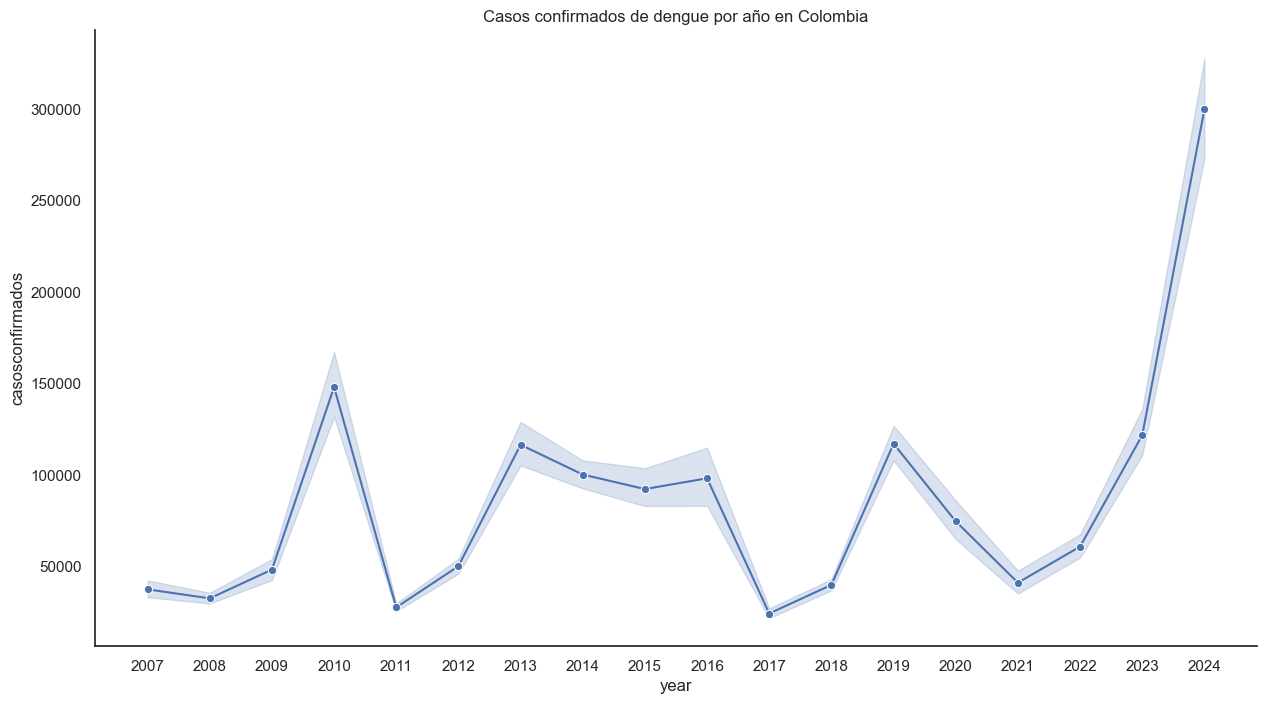

In [85]:
#* Casos confirmados por año
plt.figure(figsize=(15,8))
for col in ['year', 'mes']:
    df[col] = df[col].astype(int)
#* plotting but making year to not display decimal points in x axis
sns.lineplot(data=df, x='year', y='casosconfirmados', estimator='sum', marker='o')
plt.xticks(df['year'].unique())  # Asegura que solo se muestren los años presentes en el DataFrame

# remove borders right and top
sns.despine()
plt.title('Casos confirmados de dengue por año en Colombia')

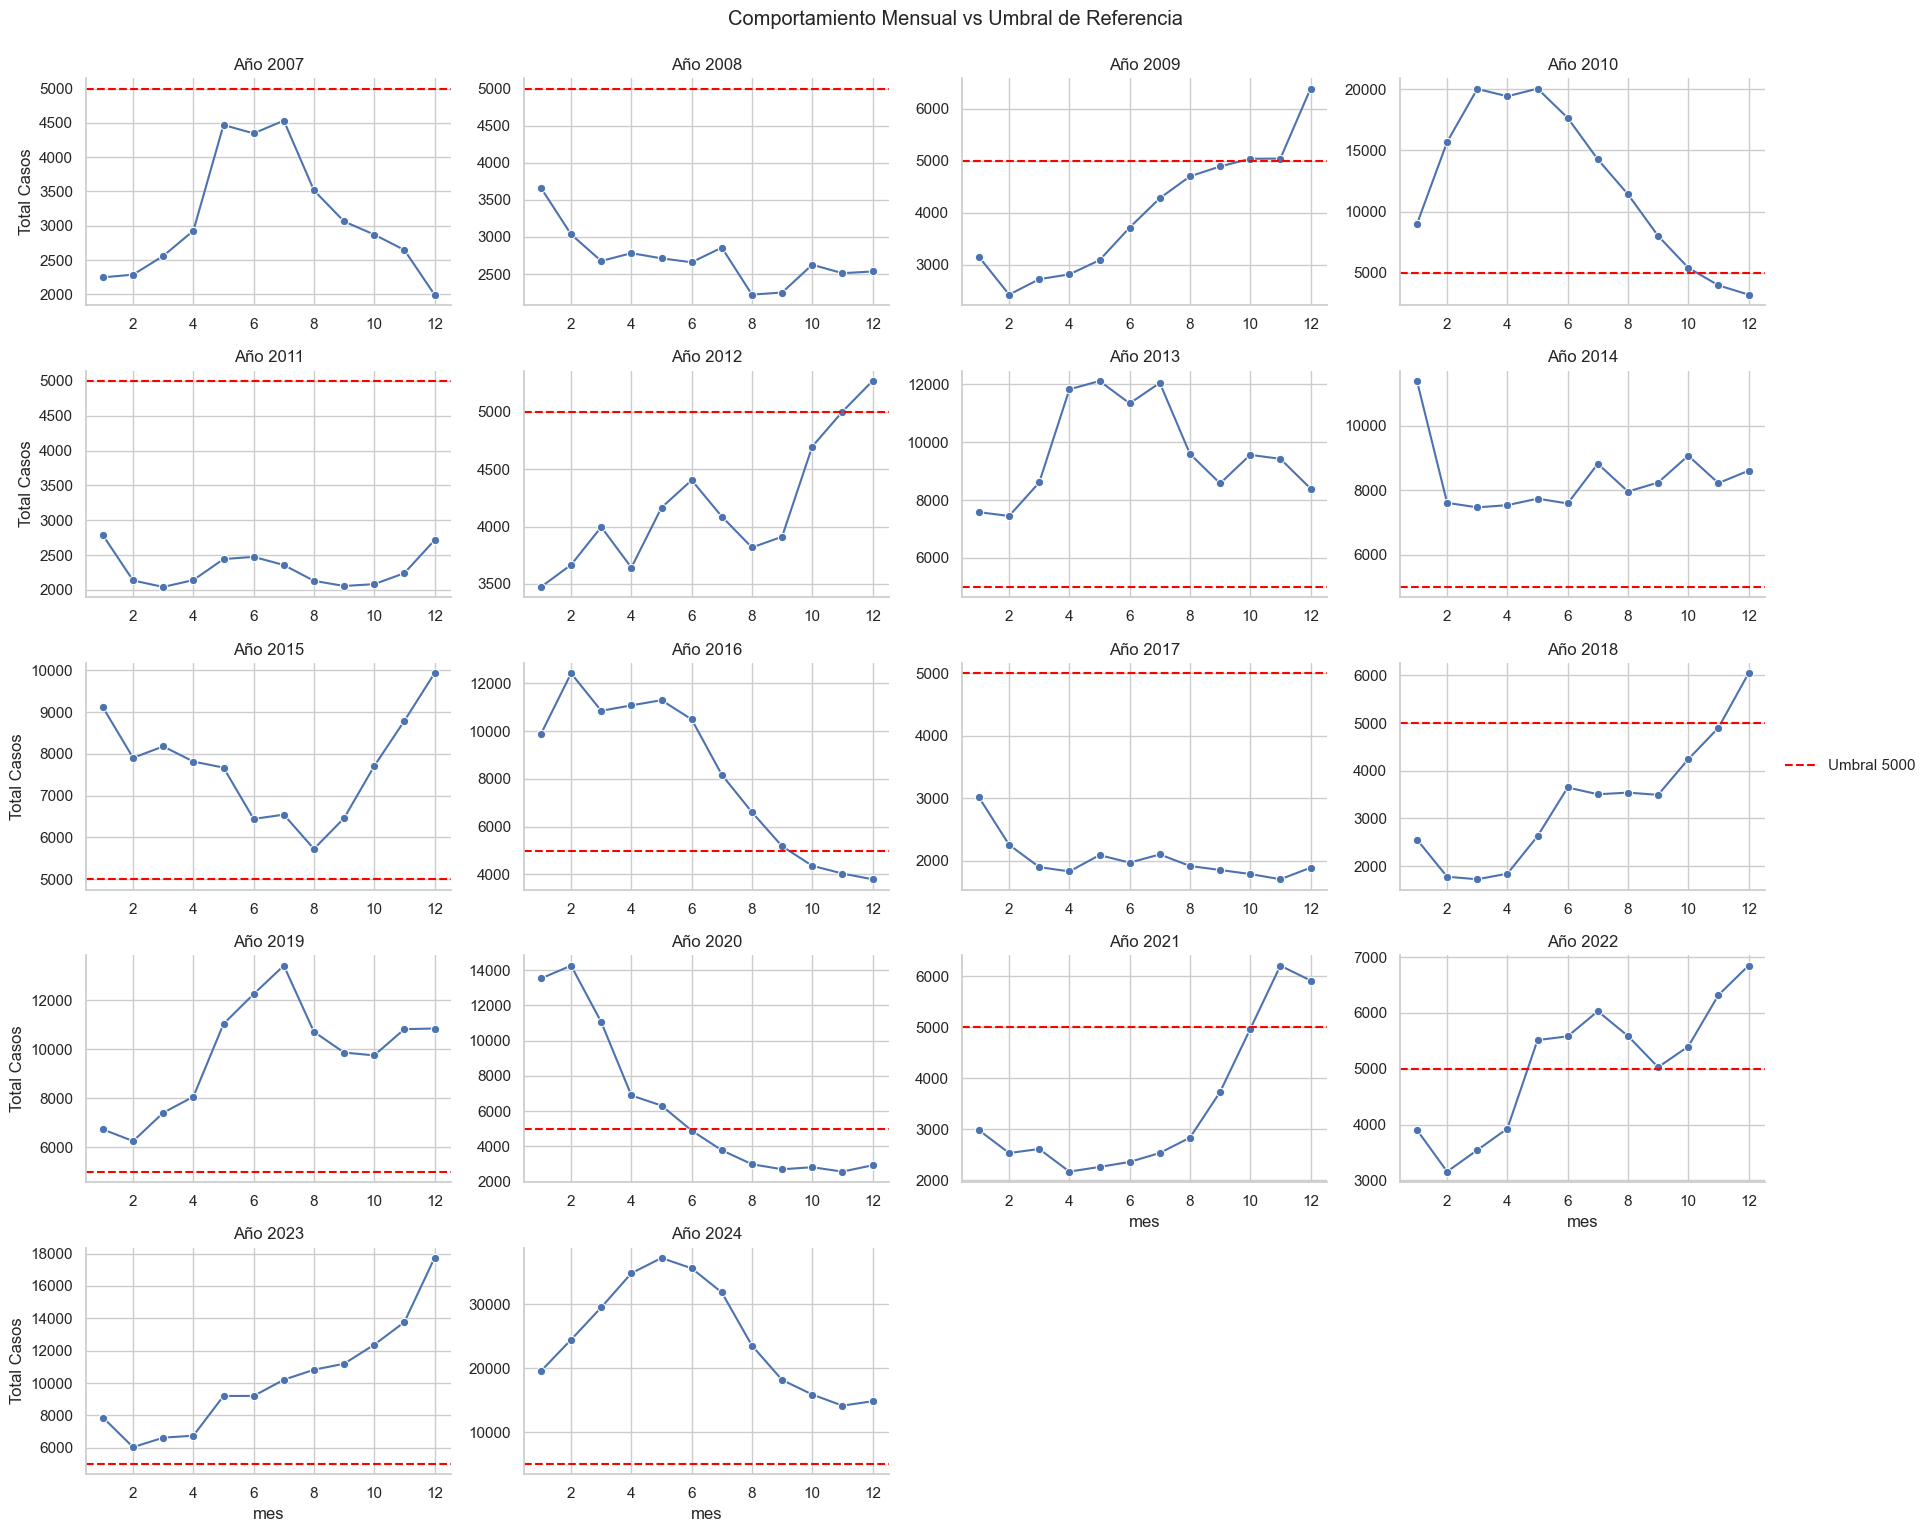

In [86]:
df['mes'] = df['mes'].apply(lambda x: int(x))
frecuencia_mensual_con_umbral(df)

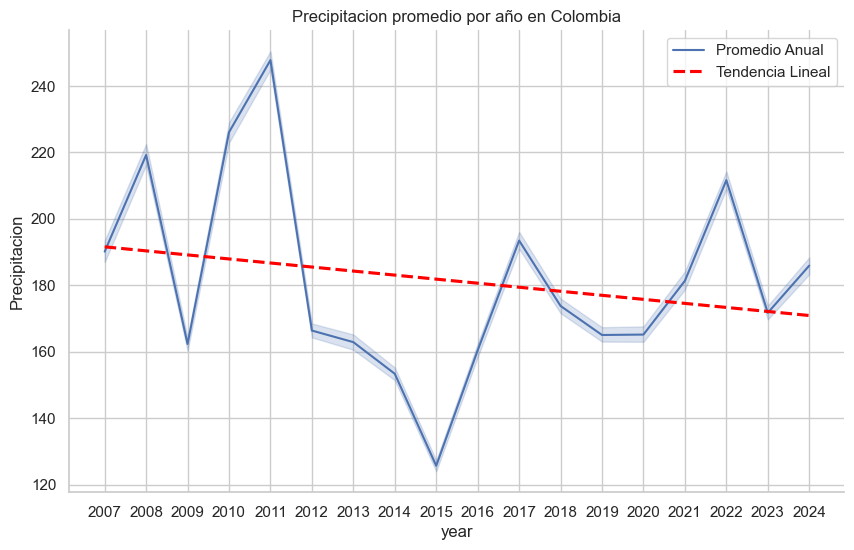

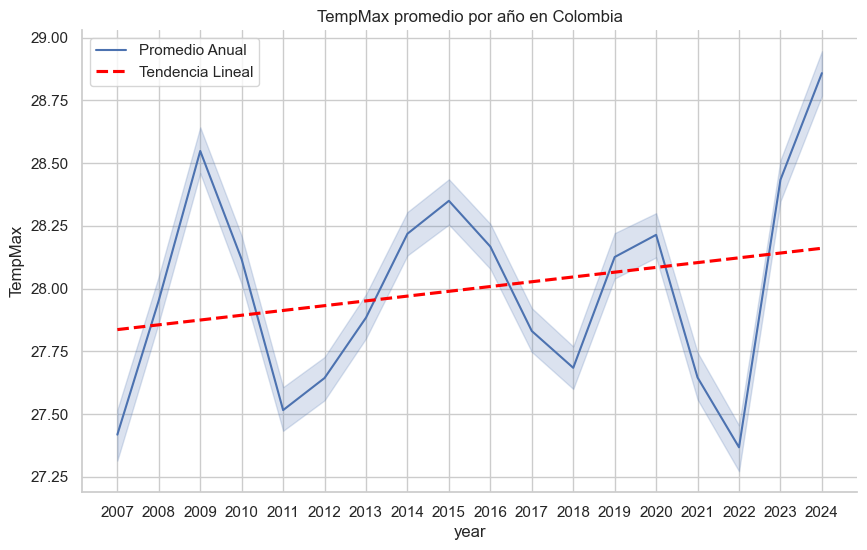

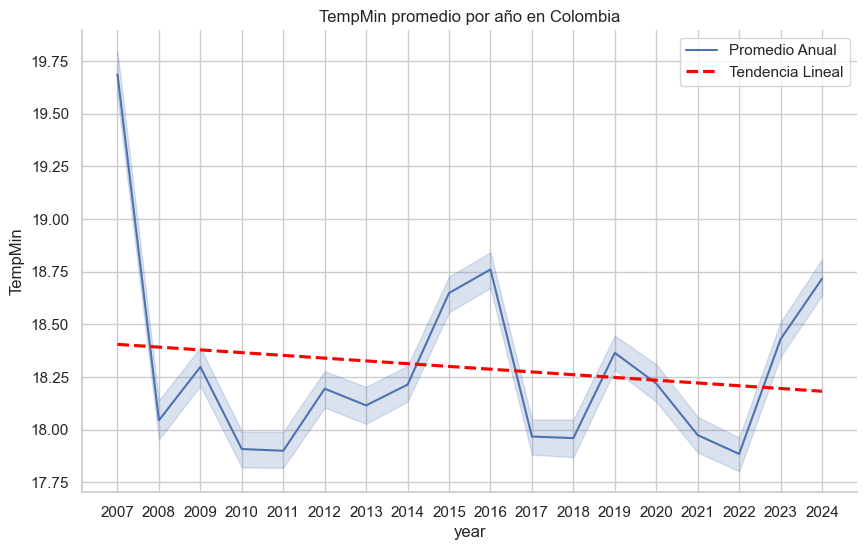

In [87]:
#* temperaturas y precipitacion promedio por año
cols = ['Precipitacion','TempMax','TempMin']
df['year'] = df['year'].astype(int)
for col in cols:
    plt.figure(figsize=(10, 6))
    
    # 1. Tu gráfica original (Línea de promedios anuales)
    sns.lineplot(data=df, x='year', y=col, estimator='mean', label='Promedio Anual')
    
    # 2. Preparar datos para la tendencia (Agrupamos por año para obtener el promedio)
    # Esto es necesario porque lineplot agrega internamente, pero para calcular la tendencia
    # necesitamos los puntos exactos (x, y) de esos promedios.
    df_trend = df.groupby('year')[col].mean().reset_index()
    
    # 3. Graficar la línea de tendencia usando regplot
    # scatter=False evita que pinte los puntos de nuevo, solo queremos la línea
    # ci=None quita la sombra del intervalo de confianza (opcional, puedes dejarlo si prefieres)
    sns.regplot(data=df_trend, x='year', y=col, scatter=False, color='red', line_kws={'linestyle':'--'}, label='Tendencia Lineal', ci=None)
    
    plt.title(f'{col} promedio por año en Colombia')
    plt.xticks(df['year'].unique())  # Asegura que solo se muestren los años presentes en el DataFrame
    plt.legend()
    sns.despine()
    plt.show()
    



In [88]:
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0,nino_mod
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0,neutral
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0,neutral
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0,neutral
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202171,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0,neutral
202172,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0,neutral
202173,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0,neutral
202174,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0,neutral


In [89]:
# crear df con rezago de temperaturas y precipitacion
df_lag = df.copy()

df_lag.sort_values(['departamento', 'municipio', 'year', 'mes'], inplace=True)

df_lag.reset_index(drop=True, inplace=True)
df_lag

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0,nino_mod
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0,neutral
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0,neutral
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0,neutral
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0,neutral
201776,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0,neutral
201777,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0,neutral
201778,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0,neutral


In [90]:
def lag_features(df, group_cols, target_cols, lags):
    for target in target_cols:
        for lag in lags:
            lag_col_name = f"{target}_Lag{lag}"
            df[lag_col_name] = df.groupby(group_cols)[target].shift(lag)
    return df


df_lag = lag_features(df_lag, group_cols=['departamento', 'municipio'],
                      target_cols=['Precipitacion', 'TempMax', 'TempMin', 'fenomeno'],
                      lags=[1, 2, 3,4,5,6,7,8])

df_lag.head(20)


,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,391.1,31.0,22.0,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,144.6,32.0,23.0,neutral,391.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,568.9,30.0,22.0,neutral,144.6,391.1,NaN,NaN,NaN,NaN,NaN,NaN,32.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,538.6,30.0,22.0,neutral,568.9,144.6,391.1,NaN,NaN,NaN,NaN,NaN,30.0,32.0,31.0,NaN,NaN,NaN,NaN,NaN,22.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.74806,158,392.1,29.0,22.0,neutral,538.6,568.9,144.6,391.1,NaN,NaN,NaN,NaN,30.0,30.0,32.0,31.0,NaN,NaN,NaN,NaN,22.0,22.0,23.0,22.0,NaN,NaN,NaN,NaN,neutral,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN
5,amazonas,el encanto,2007-06-01,colombia,2007,6,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,179.7,30.0,21.0,neutral,392.1,538.6,568.9,144.6,391.1,NaN,NaN,NaN,29.0,30.0,30.0,32.0,31.0,NaN,NaN,NaN,22.0,22.0,22.0,23.0,22.0,NaN,NaN,NaN,neutral,neutral,neutral,neutral,nino_mod,NaN,NaN,NaN
6,amazonas,el encanto,2007-07-01,colombia,2007,7,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,234.1,29.0,20.0,neutral,179.7,392.1,538.6,568.9,144.6,391.1,NaN,NaN,30.0,29.0,30.0,30.0,32.0,31.0,NaN,NaN,21.0,22.0,22.0,22.0,23.0,22.0,NaN,NaN,neutral,neutral,neutral,neutral,neutral,nino_mod,NaN,NaN
7,amazonas,el encanto,2007-08-01,colombia,2007,8,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,199.1,30.0,21.0,nina_mod,234.1,179.7,392.1,538.6,568.9,144.6,391.1,NaN,29.0,30.0,29.0,30.0,30.0,32.0,31.0,NaN,20.0,21.0,22.0,22.0,22.0,23.0,22.0,NaN,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod,NaN
8,amazonas,el encanto,2007-09-01,colombia,2007,9,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,296.3,32.0,21.0,nina_mod,199.1,234.1,179.7,392.1,538.6,568.9,144.6,391.1,30.0,29.0,30.0,29.0,30.0,30.0,32.0,31.0,21.0,20.0,21.0,22.0,22.0,22.0,23.0,22.0,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod
9,amazonas,el encanto,2007-10-01,colombia,2007,10,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,331.8,31.0,22.0,nina_mod,296.3,199.1,234.1,179.7,392.1,538.6,568.9,144.6,32.0,30.0,29.0,30.0,29.0,30.0,30.0,32.0,21.0,21.0,20.0,21.0,22.0,22.0,22.0,23.0,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral


In [91]:
df_lag.reset_index(drop=True, inplace=True)
df_lag.head()

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,391.1,31.0,22.0,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,144.6,32.0,23.0,neutral,391.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,568.9,30.0,22.0,neutral,144.6,391.1,NaN,NaN,NaN,NaN,NaN,NaN,32.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,538.6,30.0,22.0,neutral,568.9,144.6,391.1,NaN,NaN,NaN,NaN,NaN,30.0,32.0,31.0,NaN,NaN,NaN,NaN,NaN,22.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.74806,158,392.1,29.0,22.0,neutral,538.6,568.9,144.6,391.1,NaN,NaN,NaN,NaN,30.0,30.0,32.0,31.0,NaN,NaN,NaN,NaN,22.0,22.0,23.0,22.0,NaN,NaN,NaN,NaN,neutral,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN


In [92]:
df_lag.shape

(201780, 48)

In [93]:
df_lag.to_csv(f'data/dengue_data_v3_{hoja_start}.csv', index=False, sep='|')

#* Eliminar filas con nan en las columnas de los rezagos, ya que no se pueden usar para graficar
lag_cols = [col for col in df_lag.columns if 'Lag' in col]
df_lag.dropna(subset=lag_cols, inplace=True)

In [94]:
# df_lag agrupado por mes en un año especifico
df_lag_2 = df_lag[df_lag['year'] == 2023]
df_lag_2 = df_lag_2.groupby(['year', 'mes'])[['casosconfirmados',
                                   'Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1',
                                   'Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2',
                                   'Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']].agg({'casosconfirmados': 'sum',
                                                                                              'Precipitacion_Lag1': 'mean', 'TempMax_Lag1': 'mean', 'TempMin_Lag1': 'mean',
                                                                                              'Precipitacion_Lag2': 'mean', 'TempMax_Lag2': 'mean', 'TempMin_Lag2': 'mean',
                                                                                              'Precipitacion_Lag3': 'mean', 'TempMax_Lag3': 'mean', 'TempMin_Lag3': 'mean'}).reset_index(drop=False)

In [95]:
# normalizar variables no temporales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_lag_2[['Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1']])
df_lag_2[['Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2']])
df_lag_2[['Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']])

df_lag_2['casosconfirmados'] = scaler.fit_transform(df_lag_2[['casosconfirmados']])

df_lag_2

,year,mes,casosconfirmados,Precipitacion_Lag1,TempMax_Lag1,TempMin_Lag1,Precipitacion_Lag2,TempMax_Lag2,TempMin_Lag2,Precipitacion_Lag3,TempMax_Lag3,TempMin_Lag3
0,2023,1,-0.706388,-1.291398,-1.566375,-1.491992,1.966815,-2.144980,-0.854404,1.670110,-1.129470,-0.046701
1,2023,2,-1.273792,-0.099023,-1.196990,-2.031031,-1.233193,-1.045475,-1.341422,1.830125,-1.904842,-0.824200
2,2023,3,-1.091789,-1.891299,0.343573,-1.148088,-0.271674,-0.760469,-1.866048,-1.203246,-0.870165,-1.314156
3,2023,4,-1.053652,-0.054433,-0.554505,-0.085466,-1.716947,0.428184,-1.006715,-0.291798,-0.601962,-1.841947
4,2023,5,-0.293082,1.216760,-0.964155,0.362767,-0.235717,-0.264747,0.027494,-1.661809,0.516607,-0.977429
5,2023,6,-0.292461,0.874637,-0.001303,1.547108,0.789359,-0.580820,0.463742,-0.257713,-0.135468,0.063019
6,2023,7,0.017596,-0.138625,0.129995,0.782020,0.513475,0.162088,1.616415,0.713984,-0.432906,0.501899
7,2023,8,0.209211,0.176400,1.075341,0.911466,-0.303609,0.263394,0.871784,0.452466,0.266200,1.661526
8,2023,9,0.324242,0.248280,1.495047,0.375154,-0.051007,0.980646,0.979210,-0.321631,0.352093,0.893864
9,2023,10,0.688559,-0.792051,1.767859,0.207244,0.008387,1.316627,0.475798,-0.082621,1.036496,1.020476


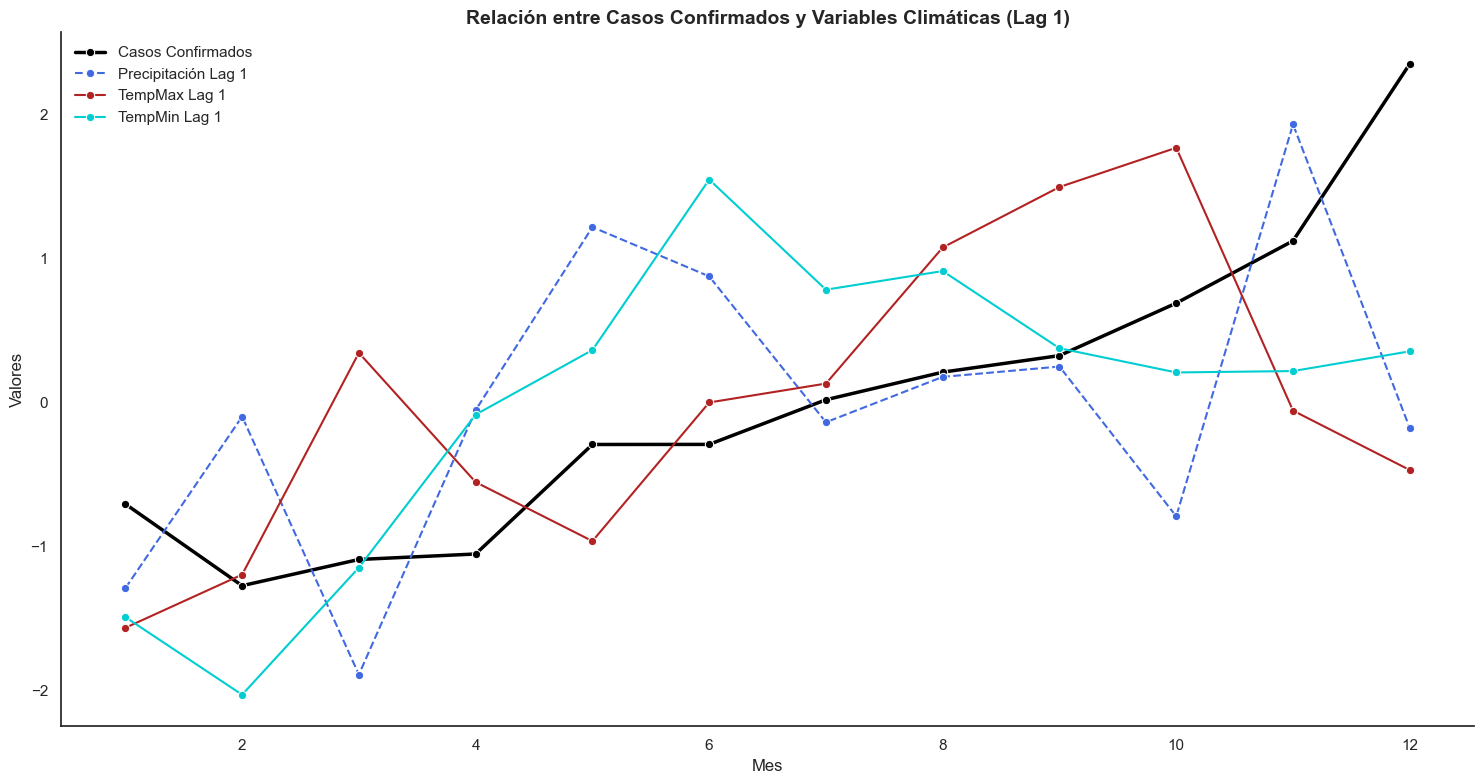

In [96]:
# line graph of CasosConfirmados vs Precipitacion_Lag1, TempMax_Lag1 and TempMin_Lag1
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='mes', y='casosconfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='mes', y='Precipitacion_Lag1', 
             marker='o', label='Precipitación Lag 1', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='mes', y='TempMax_Lag1', 
             marker='o', label='TempMax Lag 1', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='mes', y='TempMin_Lag1', 
             marker='o', label='TempMin Lag 1', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 1)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()



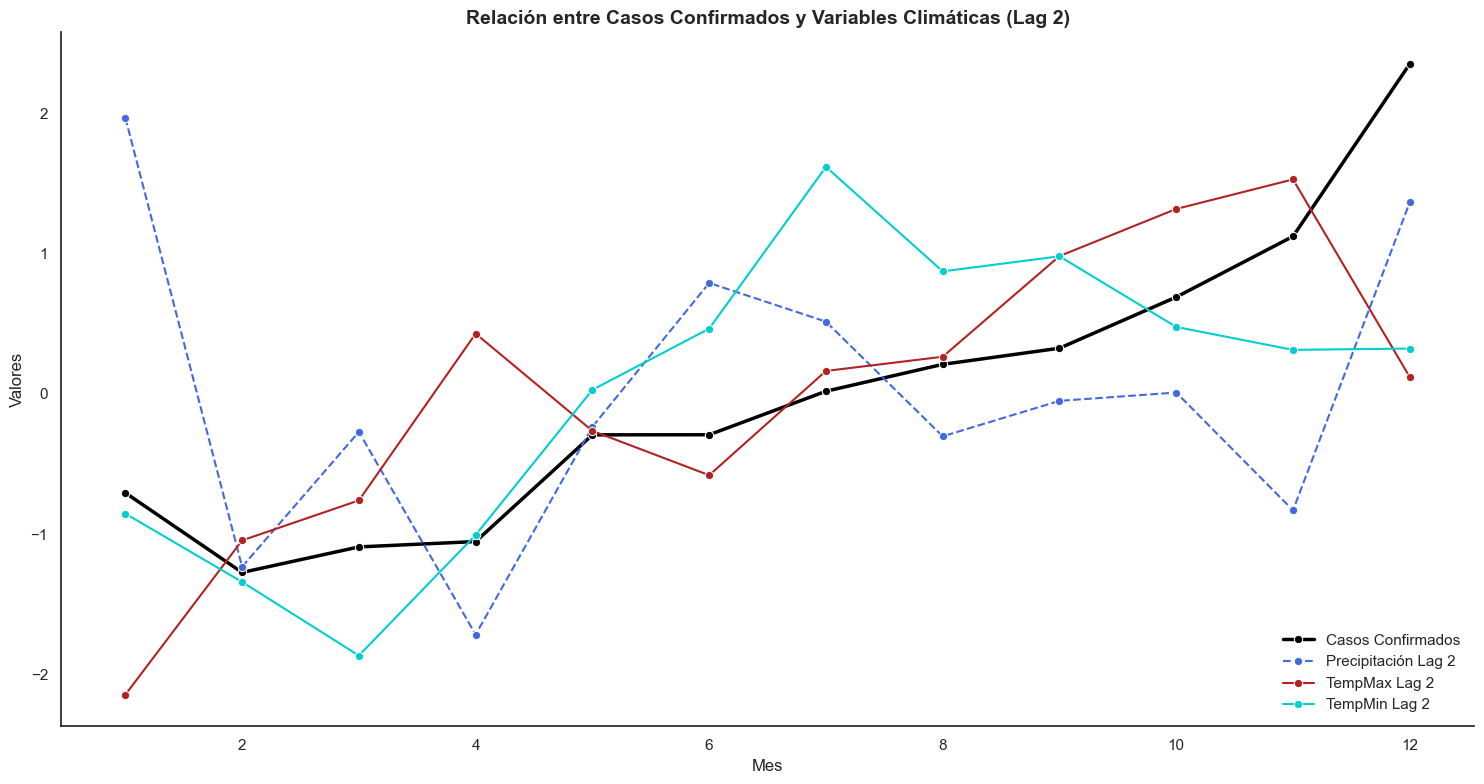

In [97]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='mes', y='casosconfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='mes', y='Precipitacion_Lag2', 
             marker='o', label='Precipitación Lag 2', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='mes', y='TempMax_Lag2', 
             marker='o', label='TempMax Lag 2', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='mes', y='TempMin_Lag2', 
             marker='o', label='TempMin Lag 2', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 2)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

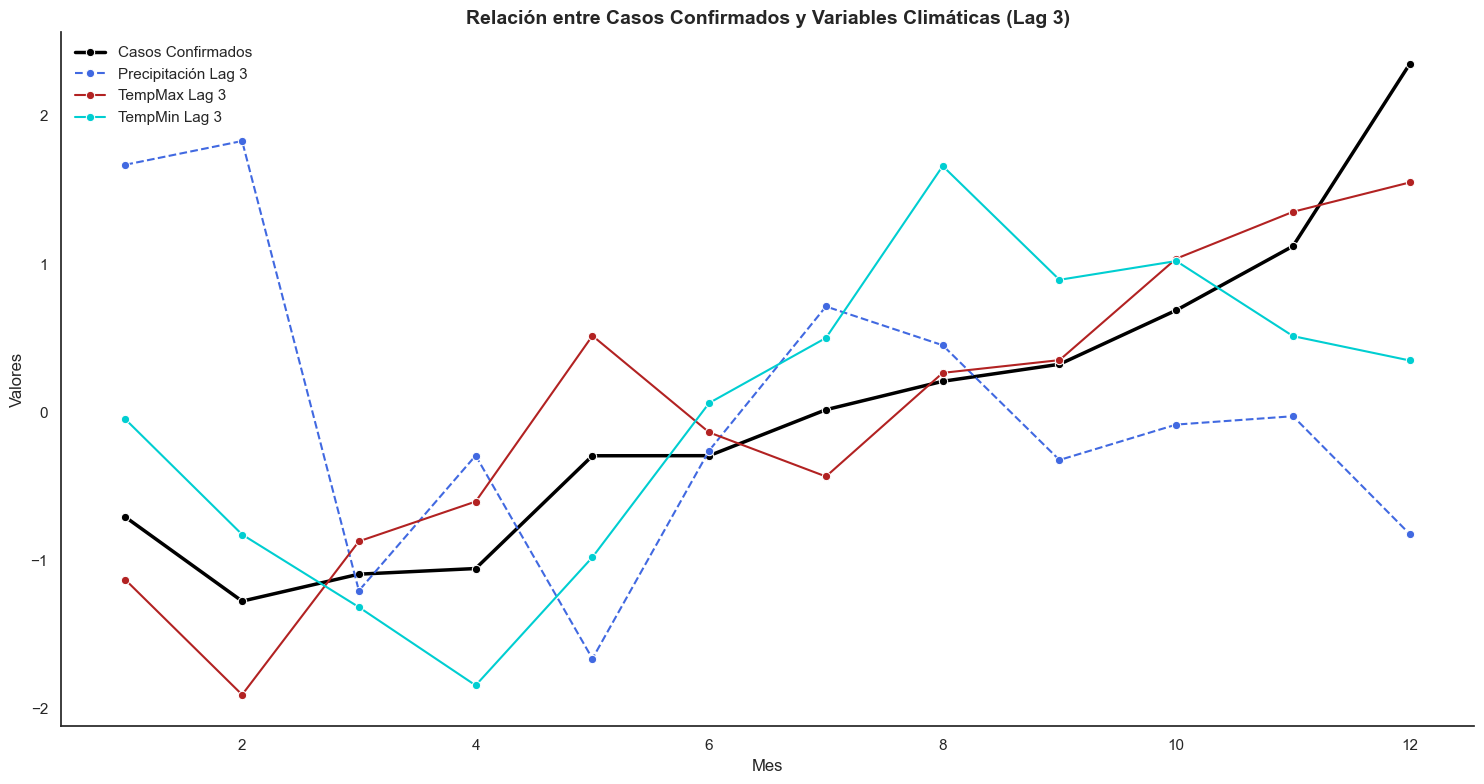

In [98]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='mes', y='casosconfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='mes', y='Precipitacion_Lag3', 
             marker='o', label='Precipitación Lag 3', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='mes', y='TempMax_Lag3', 
             marker='o', label='TempMax Lag 3', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='mes', y='TempMin_Lag3', 
             marker='o', label='TempMin Lag 3', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 3)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

## 3. Modelado de datos

En esta sección se realizan cambios importantes en el Data set, pues se prepara para su uso en modelamiento, uno de los primeros cambios viene tras la identificación de los vacios propios en los registros de cada municipio, para ser precisos se buscaba identificar que municipios presentaban registros con saltos, es decir, que para años especificos no tengan registros, la estrategia para imputar datos consiste en hacerlo sobre la misma serie del municipio, esto depende de que el municipio presente datos para ese men de al menos 4 años antes de manera continua así el valor de inputación corresponde al promedio de años anteriores. Por otro lado, esta estrategia de imputación solo se aplico a municipios que se encontraban en departamentos que tuvieran la mayor cantidad de datos en buen estado con series de tiempo completas de al menos 10 años para al menos el 80% de sus municipios.

Tras la imputación lo que siguió fue preparar las variables a utilizar realizando codificación en las variables categoricas y haciendo el proceso de escalado para las variables numericas en su mayoría, por ahora se dejan separas del proceso de escalamiento a la variable objetivo 'casosconfirmados' y a las variables de localización 'latitud' y 'longitud'.

Se realiza un análisis de correlación con la data resultante, se nota que hay variables que están fuertemente correalcionadas, como lo son las temperaturas maxima y minima entre sí, cosa que persiste en sus rezagos, además la temperatura en general esta fuertemente relacionada con la elevación. Como corrección se plantea la eliminación de la variable de elevacion y en cambia se va a suavizar la temperatura tomando un valor medio entre la temperatura max y minima.

In [99]:
df = pd.read_csv(f'data/dengue_data_v3_{hoja_start}.csv', sep='|')
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0,neutral,391.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0,neutral,144.6,391.1,NaN,NaN,NaN,NaN,NaN,NaN,32.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0,neutral,568.9,144.6,391.1,NaN,NaN,NaN,NaN,NaN,30.0,32.0,31.0,NaN,NaN,NaN,NaN,NaN,22.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0,neutral,538.6,568.9,144.6,391.1,NaN,NaN,NaN,NaN,30.0,30.0,32.0,31.0,NaN,NaN,NaN,NaN,22.0,22.0,23.0,22.0,NaN,NaN,NaN,NaN,neutral,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0,neutral,325.7,431.9,340.8,231.1,70.7,31.3,15.9,37.8,30.0,29.0,31.0,33.0,35.0,36.0,35.0,32.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,23.0,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev
201776,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0,neutral,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,31.0,30.0,29.0,31.0,33.0,35.0,36.0,35.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev
201777,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0,neutral,211.5,255.6,325.7,431.9,340.8,231.1,70.7,31.3,32.0,31.0,30.0,29.0,31.0,33.0,35.0,36.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod
201778,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0,neutral,238.2,211.5,255.6,325.7,431.9,340.8,231.1,70.7,32.0,32.0,31.0,30.0,29.0,31.0,33.0,35.0,23.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod


In [100]:
# verificacion de cuantos municipios por departamento tienen una serie completa de datos (2007-2024) para cada mes
# depts = ['valle del cauca','santander','tolima', 'antioquia', 'meta', 'huila','norte de santander','atlantico','bolivar','cesar']
# depts = ['cundinamarca', 'boyaca']
depts = df['departamento'].unique()
depts_full = []
depts_15 = []
depts_12 = []
depts_10 = []
for dept in depts:
# dept = 'antioquia'
    df_dept = df[df['departamento'] == dept]
    df_dept['year'] = df_dept['year'].astype(int)

    full = [] #18*12
    al_menos_15 = [] #15*12
    al_menos_12 = [] #12*12
    al_menos_10 = [] #10*12
    al_menos_5 =[] #5*12
    menos_de_5 = [] #menos de 5*12
    for muni in df_dept['municipio'].unique():
        df_muni = df_dept[df_dept['municipio'] == muni]
        count = df_muni.groupby(['year', 'mes']).size().reset_index(name='Count')
        # count if not nan values in CasosConfirmados column
        count = df_muni[~df_muni['casosconfirmados'].isna()].groupby(['year', 'mes']).size().reset_index(name='Count')
        count_total = count['Count'].sum()
        if count_total == (18*12): 
            full.append(muni)
        elif count_total >= 15*12:
            al_menos_15.append(muni)
        elif count_total >= 12*12:
            al_menos_12.append(muni)
        elif count_total >= 10*12:
            al_menos_10.append(muni)
        elif count_total >= 5*12:
            al_menos_5.append(muni)
        else:
            menos_de_5.append(muni)
        del df_muni, count
    #* si el departamente tiene un 80% o mas de sus municipios con serie completa de datos, agregarlo a la lista de departamentos con buena cobertura
    if len(full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_full.append(dept)
    if len(al_menos_15+full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_15.append(dept)
    if len(al_menos_12+al_menos_15+full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_12.append(dept)
    if len(al_menos_10+al_menos_12+al_menos_15+full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_10.append(dept)

    print(f"Municipios del {dept} con serie completa de datos (18 años): {len(full)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 15 años de datos: {len(al_menos_15)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 12 años de datos: {len(al_menos_12)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 10 años de datos: {len(al_menos_10)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 5 años de datos: {len(al_menos_5)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con menos de 5 años de datos: {len(menos_de_5)/len(df_dept['municipio'].unique())*100:.2f}%")
    print("\n")

Municipios del amazonas con serie completa de datos (18 años): 9.09%
Municipios del amazonas con al menos 15 años de datos: 0.00%
Municipios del amazonas con al menos 12 años de datos: 9.09%
Municipios del amazonas con al menos 10 años de datos: 9.09%
Municipios del amazonas con al menos 5 años de datos: 27.27%
Municipios del amazonas con menos de 5 años de datos: 45.45%


Municipios del antioquia con serie completa de datos (18 años): 11.57%
Municipios del antioquia con al menos 15 años de datos: 32.23%
Municipios del antioquia con al menos 12 años de datos: 20.66%
Municipios del antioquia con al menos 10 años de datos: 10.74%
Municipios del antioquia con al menos 5 años de datos: 20.66%
Municipios del antioquia con menos de 5 años de datos: 4.13%


Municipios del arauca con serie completa de datos (18 años): 71.43%
Municipios del arauca con al menos 15 años de datos: 28.57%
Municipios del arauca con al menos 12 años de datos: 0.00%
Municipios del arauca con al menos 10 años de datos:

In [101]:
# depts_full
# depts_15
# depts_12
depts_10

['arauca',
 'archipielago de san andres, providencia y santa catalina',
 'atlantico',
 'bolivar',
 'caqueta',
 'casanare',
 'cesar',
 'choco',
 'cordoba',
 'guaviare',
 'huila',
 'la guajira',
 'magdalena',
 'meta',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca',
 'vichada']

In [102]:
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0,neutral,391.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0,neutral,144.6,391.1,NaN,NaN,NaN,NaN,NaN,NaN,32.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0,neutral,568.9,144.6,391.1,NaN,NaN,NaN,NaN,NaN,30.0,32.0,31.0,NaN,NaN,NaN,NaN,NaN,22.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0,neutral,538.6,568.9,144.6,391.1,NaN,NaN,NaN,NaN,30.0,30.0,32.0,31.0,NaN,NaN,NaN,NaN,22.0,22.0,23.0,22.0,NaN,NaN,NaN,NaN,neutral,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0,neutral,325.7,431.9,340.8,231.1,70.7,31.3,15.9,37.8,30.0,29.0,31.0,33.0,35.0,36.0,35.0,32.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,23.0,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev
201776,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0,neutral,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,31.0,30.0,29.0,31.0,33.0,35.0,36.0,35.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev
201777,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0,neutral,211.5,255.6,325.7,431.9,340.8,231.1,70.7,31.3,32.0,31.0,30.0,29.0,31.0,33.0,35.0,36.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod
201778,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0,neutral,238.2,211.5,255.6,325.7,431.9,340.8,231.1,70.7,32.0,32.0,31.0,30.0,29.0,31.0,33.0,35.0,23.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod


In [103]:
discontinuos = {}
for dept in depts_10:
    df_dept = df[df['departamento'] == dept]
    for muni in df_dept['municipio'].unique():
        años = []
        df_muni = df_dept[df_dept['municipio'] == muni]    
        #* tomamos el minimo año y el maximo por en el municipio para identificar si hay saltos de meses o años en la serie de datos
        min_year = df_muni['year'].min()
        max_year = df_muni['year'].max()
        #* identificar municipios que tienen salto de mes en algn año
        for year in range(min_year, max_year+1):
            df_year = df_muni[df_muni['year'] == year]
            #* si el año es el primero de la serie, esperamos que no tenga los primeros 3 meses por los rezagos, pero si el año es el ultimo de la serie, esperamos que no tenga los ultimos 3 meses por los rezagos, en caso contrario, esperamos que tenga los 12 meses
            meses_esperados = set(range(1,13))
            #* meses presentes son sin nan en CasosConfirmados
            # meses_presentes = set(df_year['Mes'].unique())
            meses_presentes = set(df_year[~df_year['casosconfirmados'].isna()]['mes'].unique())
            if meses_esperados != meses_presentes:
                #* si faltan todos los meses 
                if len(meses_presentes) == 0:
                    print(f"El municipio {muni} en el departamento {dept} no tiene datos para el año {year}.")
                else:
                    print(f"El municipio {muni} en el departamento {dept} tiene salto de meses en el año {year}. Meses faltantes: {meses_esperados-meses_presentes}")
                años.append(year)
        if len(años) > 0:
            if dept not in discontinuos:
                discontinuos[f"{dept}"] = {f"{muni}": años}
            else:
                discontinuos[f"{dept}"][f"{muni}"] = años

El municipio cravo norte en el departamento arauca no tiene datos para el año 2020.
El municipio cravo norte en el departamento arauca no tiene datos para el año 2022.
El municipio puerto rondon en el departamento arauca no tiene datos para el año 2016.
El municipio puerto rondon en el departamento arauca no tiene datos para el año 2020.
El municipio puerto rondon en el departamento arauca no tiene datos para el año 2021.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2008.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2009.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2010.


El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2011.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2017.
El municipio campo de la cruz en el departamento atlantico no tiene datos para el año 2012.
El municipio campo de la cruz en el departamento atlantico no tiene datos para el año 2016.
El municipio campo de la cruz en el departamento atlantico no tiene datos para el año 2018.
El municipio manati en el departamento atlantico no tiene datos para el año 2016.
El municipio piojo en el departamento atlantico no tiene datos para el año 2012.
El municipio piojo en el departamento atlantico no tiene datos para el año 2017.
El municipio piojo en el departamento atlantico no tiene datos para el año 2019.
El municipio polonuevo en el departamento atlantico no tiene datos para el año 2010.
El municipio repelon en el departamento atlant

In [104]:
# Calcular perdida de datos por departamento considerando los municipios con saltos
perdida_por_dept = {}
for dept, munis in discontinuos.items():
    total_municipios = len(df[df['departamento'] == dept]['municipio'].unique())
    municipios_con_saltos = len(munis)
    perdida_por_dept[dept] = (municipios_con_saltos / total_municipios) * 100
    print(f"Departamento: {dept}, Municipios con saltos: {municipios_con_saltos}/{total_municipios} ({perdida_por_dept[dept]:.2f}%)")

Departamento: arauca, Municipios con saltos: 2/7 (28.57%)
Departamento: archipielago de san andres, providencia y santa catalina, Municipios con saltos: 1/2 (50.00%)
Departamento: atlantico, Municipios con saltos: 7/22 (31.82%)
Departamento: bolivar, Municipios con saltos: 26/44 (59.09%)
Departamento: caqueta, Municipios con saltos: 12/16 (75.00%)
Departamento: casanare, Municipios con saltos: 4/19 (21.05%)
Departamento: cesar, Municipios con saltos: 3/24 (12.50%)
Departamento: choco, Municipios con saltos: 26/31 (83.87%)
Departamento: cordoba, Municipios con saltos: 8/28 (28.57%)
Departamento: guaviare, Municipios con saltos: 1/4 (25.00%)
Departamento: huila, Municipios con saltos: 9/37 (24.32%)
Departamento: la guajira, Municipios con saltos: 6/15 (40.00%)
Departamento: magdalena, Municipios con saltos: 19/28 (67.86%)
Departamento: meta, Municipios con saltos: 6/29 (20.69%)
Departamento: norte de santander, Municipios con saltos: 21/39 (53.85%)
Departamento: quindio, Municipios con s

In [105]:
# 1. Safer way to identify variables (avoiding metadata/time columns)
exclude_cols = ['departamento', 'municipio', 'year', 'mes', 'tipomunicipio', 'longitud', 'latitud', 'cod_muni', 'date']
vars_to_impute = [c for c in df.columns if c not in exclude_cols]
vars_to_impute =['casosconfirmados']  # Focusing on the main target variable for imputation
for dept in depts_10:
    df_dept = df[df['departamento'] == dept]
    for muni in df_dept['municipio'].unique():
        # Get a slice for the current municipality
        df_muni = df_dept[df_dept['municipio'] == muni]
        
        # Get basic info
        min_year = df_muni['year'].min()
        
        # 2. Identify indices where CasosConfirmados is NaN 
        # (Assuming these rows were created by your grid completion step)
        nan_indices = df_muni[df_muni['casosconfirmados'].isna()].index
        
        for idx in nan_indices:
            # Retrieve the row data from the main DF using the index
            row = df.loc[idx]
            year = row['year']
            mes = row['mes']
            
            # Logic check: Only impute if it meets your "expected months" criteria 
            # (e.g., month >= 4 if it's the first year)
            if year == min_year and mes < 4:
                continue
                
            # 3. Filter historical data for the same month across previous years
            # We ensure we only use rows that HAVE data (notna) to calculate the mean
            df_hist = df_muni[
                (df_muni['year'] < year) & 
                (df_muni['mes'] == mes) & 
                (df_muni['casosconfirmados'].notna())
            ]
            
            if len(df_hist) >= 4:
                # 4. Impute values directly into the existing row in the main 'df'
                for v in vars_to_impute:
                    mean_val = df_hist[v].astype(float).mean()
                    df.loc[idx, v] = mean_val
                
                print(f"Imputado: {muni} ({dept}) para {year}-{mes} usando {len(df_hist)} años previos.")
            else:
                print(f"No se pudo imputar: {muni} ({dept}) para {year}-{mes} (Datos insuficientes: {len(df_hist)})")


Imputado: cravo norte (arauca) para 2020-1 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-2 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-3 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-4 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-5 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-6 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-7 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-8 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-9 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-10 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-11 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-12 usando 12 años previos.
Imputado: cravo norte (arauca) para 2022-1 usando 13 años previos.
Imputado: cravo norte (arauca) para 2022-2 usando 13 años previos.
Imputado: cravo norte (arauca) para 2022-3 usando 13 años p

Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-6 usando 6 años previos.
Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-7 usando 6 años previos.
Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-8 usando 6 años previos.
Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-9 usando 6 años previos.
Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-10 usando 6 años previos.
Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-11 usando 6 años previos.
Imputado: providencia (archipielago de san andres, providencia y santa catalina) para 2017-12 usando 6 años previos.
Imputado: campo de la cruz (atlantico) para 2012-1 usando 5 años previos.
Imputado: campo de la cruz (atlantico) para 2012-2 usando 5 años previos.
Imputado: campo de la cruz (atlantico

In [106]:
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0,neutral,391.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0,neutral,144.6,391.1,NaN,NaN,NaN,NaN,NaN,NaN,32.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN,NaN
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0,neutral,568.9,144.6,391.1,NaN,NaN,NaN,NaN,NaN,30.0,32.0,31.0,NaN,NaN,NaN,NaN,NaN,22.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN,NaN
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0,neutral,538.6,568.9,144.6,391.1,NaN,NaN,NaN,NaN,30.0,30.0,32.0,31.0,NaN,NaN,NaN,NaN,22.0,22.0,23.0,22.0,NaN,NaN,NaN,NaN,neutral,neutral,neutral,nino_mod,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0,neutral,325.7,431.9,340.8,231.1,70.7,31.3,15.9,37.8,30.0,29.0,31.0,33.0,35.0,36.0,35.0,32.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,23.0,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev
201776,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0,neutral,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,31.0,30.0,29.0,31.0,33.0,35.0,36.0,35.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev
201777,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0,neutral,211.5,255.6,325.7,431.9,340.8,231.1,70.7,31.3,32.0,31.0,30.0,29.0,31.0,33.0,35.0,36.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod
201778,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0,neutral,238.2,211.5,255.6,325.7,431.9,340.8,231.1,70.7,32.0,32.0,31.0,30.0,29.0,31.0,33.0,35.0,23.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod


In [107]:
#* eliminar filas con valores faltantes en las columnas de clima rezagadas
lag_cols = [col for col in df.columns if 'Lag' in col]
df.dropna(subset=lag_cols, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 193316 entries, 8 to 201779
Data columns (total 48 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   departamento        193316 non-null  str    
 1   municipio           193316 non-null  str    
 2   date                193316 non-null  str    
 3   pais                159548 non-null  str    
 4   year                193316 non-null  int64  
 5   mes                 193316 non-null  int64  
 6   casosconfirmados    166208 non-null  float64
 7   cod_muni            193316 non-null  int64  
 8   tipo                193316 non-null  str    
 9   longitud            193316 non-null  float64
 10  latitud             193316 non-null  float64
 11  elevacion           193316 non-null  int64  
 12  Precipitacion       193316 non-null  float64
 13  TempMax             193316 non-null  float64
 14  TempMin             193316 non-null  float64
 15  fenomeno            193316 non-null  str    
 16  

In [108]:
df = df[df['departamento'].isin(depts_10)] #* Se utilizan solo los datos de los departamentos con mejor calidad de dato
df.info()


<class 'pandas.DataFrame'>
Index: 115868 entries, 24992 to 201779
Data columns (total 48 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   departamento        115868 non-null  str    
 1   municipio           115868 non-null  str    
 2   date                115868 non-null  str    
 3   pais                105248 non-null  str    
 4   year                115868 non-null  int64  
 5   mes                 115868 non-null  int64  
 6   casosconfirmados    111908 non-null  float64
 7   cod_muni            115868 non-null  int64  
 8   tipo                115868 non-null  str    
 9   longitud            115868 non-null  float64
 10  latitud             115868 non-null  float64
 11  elevacion           115868 non-null  int64  
 12  Precipitacion       115868 non-null  float64
 13  TempMax             115868 non-null  float64
 14  TempMin             115868 non-null  float64
 15  fenomeno            115868 non-null  str    
 

In [109]:
df.drop(columns=['departamento','municipio','pais','date','cod_muni','tipo'], inplace=True)
df

,year,mes,casosconfirmados,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
24992,2007,9,43.0,-70.747408,7.072726,127,170.8,30.0,23.0,nina_mod,383.8,215.1,249.9,193.6,118.0,70.8,11.2,6.6,30.0,30.0,30.0,31.0,33.0,35.0,35.0,32.0,23.0,24.0,23.0,24.0,24.0,24.0,22.0,24.0,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod
24993,2007,10,38.0,-70.747408,7.072726,127,231.1,30.0,24.0,nina_mod,170.8,383.8,215.1,249.9,193.6,118.0,70.8,11.2,30.0,30.0,30.0,30.0,31.0,33.0,35.0,35.0,23.0,23.0,24.0,23.0,24.0,24.0,24.0,22.0,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral
24994,2007,11,15.0,-70.747408,7.072726,127,100.7,32.0,23.0,nina_sev,231.1,170.8,383.8,215.1,249.9,193.6,118.0,70.8,30.0,30.0,30.0,30.0,30.0,31.0,33.0,35.0,24.0,23.0,23.0,24.0,23.0,24.0,24.0,24.0,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral
24995,2007,12,12.0,-70.747408,7.072726,127,36.4,31.0,24.0,nina_sev,100.7,231.1,170.8,383.8,215.1,249.9,193.6,118.0,32.0,30.0,30.0,30.0,30.0,30.0,31.0,33.0,23.0,24.0,23.0,23.0,24.0,23.0,24.0,24.0,nina_sev,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,neutral
24996,2008,1,25.0,-70.747408,7.072726,127,8.2,33.0,22.0,nina_sev,36.4,100.7,231.1,170.8,383.8,215.1,249.9,193.6,31.0,32.0,30.0,30.0,30.0,30.0,30.0,31.0,24.0,23.0,24.0,23.0,23.0,24.0,23.0,24.0,nina_sev,nina_sev,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,2024,8,1.0,-70.859499,5.136393,116,255.6,31.0,22.0,neutral,325.7,431.9,340.8,231.1,70.7,31.3,15.9,37.8,30.0,29.0,31.0,33.0,35.0,36.0,35.0,32.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,23.0,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev
201776,2024,9,3.0,-70.859499,5.136393,116,211.5,32.0,23.0,neutral,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,31.0,30.0,29.0,31.0,33.0,35.0,36.0,35.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,22.0,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev
201777,2024,10,2.0,-70.859499,5.136393,116,238.2,32.0,23.0,neutral,211.5,255.6,325.7,431.9,340.8,231.1,70.7,31.3,32.0,31.0,30.0,29.0,31.0,33.0,35.0,36.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,24.0,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod
201778,2024,11,0.0,-70.859499,5.136393,116,149.6,32.0,23.0,neutral,238.2,211.5,255.6,325.7,431.9,340.8,231.1,70.7,32.0,32.0,31.0,30.0,29.0,31.0,33.0,35.0,23.0,23.0,22.0,23.0,22.0,24.0,23.0,23.0,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod


In [110]:
#* Se guarda df con rezagos e imputaciones para la siguiente etapa de análisis y modelado
df.to_csv(f'data/dengue_data_v4_{hoja_start}.csv', index=False, sep='|')

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [112]:
df = pd.read_csv(f'data/dengue_data_v4_{hoja_start}.csv', sep='|')
df.head()

,year,mes,casosconfirmados,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8
0,2007,9,43.0,-70.747408,7.072726,127,170.8,30.0,23.0,nina_mod,383.8,215.1,249.9,193.6,118.0,70.8,11.2,6.6,30.0,30.0,30.0,31.0,33.0,35.0,35.0,32.0,23.0,24.0,23.0,24.0,24.0,24.0,22.0,24.0,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod
1,2007,10,38.0,-70.747408,7.072726,127,231.1,30.0,24.0,nina_mod,170.8,383.8,215.1,249.9,193.6,118.0,70.8,11.2,30.0,30.0,30.0,30.0,31.0,33.0,35.0,35.0,23.0,23.0,24.0,23.0,24.0,24.0,24.0,22.0,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral
2,2007,11,15.0,-70.747408,7.072726,127,100.7,32.0,23.0,nina_sev,231.1,170.8,383.8,215.1,249.9,193.6,118.0,70.8,30.0,30.0,30.0,30.0,30.0,31.0,33.0,35.0,24.0,23.0,23.0,24.0,23.0,24.0,24.0,24.0,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral
3,2007,12,12.0,-70.747408,7.072726,127,36.4,31.0,24.0,nina_sev,100.7,231.1,170.8,383.8,215.1,249.9,193.6,118.0,32.0,30.0,30.0,30.0,30.0,30.0,31.0,33.0,23.0,24.0,23.0,23.0,24.0,23.0,24.0,24.0,nina_sev,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,neutral
4,2008,1,25.0,-70.747408,7.072726,127,8.2,33.0,22.0,nina_sev,36.4,100.7,231.1,170.8,383.8,215.1,249.9,193.6,31.0,32.0,30.0,30.0,30.0,30.0,30.0,31.0,24.0,23.0,24.0,23.0,23.0,24.0,23.0,24.0,nina_sev,nina_sev,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral


In [113]:
# make dummies for Year and Mes
df = pd.get_dummies(df, columns=['mes'] + [i for i in df.columns if 'fenomeno' in i], drop_first=True, dtype=int)
df.head()

,year,casosconfirmados,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_Lag1_nina_mod,fenomeno_Lag1_nina_sev,fenomeno_Lag1_nino_mod,fenomeno_Lag1_nino_sev,fenomeno_Lag2_nina_mod,fenomeno_Lag2_nina_sev,fenomeno_Lag2_nino_mod,fenomeno_Lag2_nino_sev,fenomeno_Lag3_nina_mod,fenomeno_Lag3_nina_sev,fenomeno_Lag3_nino_mod,fenomeno_Lag3_nino_sev,fenomeno_Lag4_nina_mod,fenomeno_Lag4_nina_sev,fenomeno_Lag4_nino_mod,fenomeno_Lag4_nino_sev,fenomeno_Lag5_nina_mod,fenomeno_Lag5_nina_sev,fenomeno_Lag5_nino_mod,fenomeno_Lag5_nino_sev,fenomeno_Lag6_nina_mod,fenomeno_Lag6_nina_sev,fenomeno_Lag6_nino_mod,fenomeno_Lag6_nino_sev,fenomeno_Lag7_nina_mod,fenomeno_Lag7_nina_sev,fenomeno_Lag7_nino_mod,fenomeno_Lag7_nino_sev,fenomeno_Lag8_nina_mod,fenomeno_Lag8_nina_sev,fenomeno_Lag8_nino_mod,fenomeno_Lag8_nino_sev
0,2007,43.0,-70.747408,7.072726,127,170.8,30.0,23.0,383.8,215.1,249.9,193.6,118.0,70.8,11.2,6.6,30.0,30.0,30.0,31.0,33.0,35.0,35.0,32.0,23.0,24.0,23.0,24.0,24.0,24.0,22.0,24.0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2007,38.0,-70.747408,7.072726,127,231.1,30.0,24.0,170.8,383.8,215.1,249.9,193.6,118.0,70.8,11.2,30.0,30.0,30.0,30.0,31.0,33.0,35.0,35.0,23.0,23.0,24.0,23.0,24.0,24.0,24.0,22.0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2007,15.0,-70.747408,7.072726,127,100.7,32.0,23.0,231.1,170.8,383.8,215.1,249.9,193.6,118.0,70.8,30.0,30.0,30.0,30.0,30.0,31.0,33.0,35.0,24.0,23.0,23.0,24.0,23.0,24.0,24.0,24.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2007,12.0,-70.747408,7.072726,127,36.4,31.0,24.0,100.7,231.1,170.8,383.8,215.1,249.9,193.6,118.0,32.0,30.0,30.0,30.0,30.0,30.0,31.0,33.0,23.0,24.0,23.0,23.0,24.0,23.0,24.0,24.0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008,25.0,-70.747408,7.072726,127,8.2,33.0,22.0,36.4,100.7,231.1,170.8,383.8,215.1,249.9,193.6,31.0,32.0,30.0,30.0,30.0,30.0,30.0,31.0,24.0,23.0,24.0,23.0,23.0,24.0,23.0,24.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [114]:
df.to_csv(f'data/dengue_data_v5_{hoja_start}.csv', index=False, sep='|')

In [115]:
df.corr()[:20]

,year,casosconfirmados,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMax_Lag4,TempMax_Lag5,TempMax_Lag6,TempMax_Lag7,TempMax_Lag8,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3,TempMin_Lag4,TempMin_Lag5,TempMin_Lag6,TempMin_Lag7,TempMin_Lag8,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_Lag1_nina_mod,fenomeno_Lag1_nina_sev,fenomeno_Lag1_nino_mod,fenomeno_Lag1_nino_sev,fenomeno_Lag2_nina_mod,fenomeno_Lag2_nina_sev,fenomeno_Lag2_nino_mod,fenomeno_Lag2_nino_sev,fenomeno_Lag3_nina_mod,fenomeno_Lag3_nina_sev,fenomeno_Lag3_nino_mod,fenomeno_Lag3_nino_sev,fenomeno_Lag4_nina_mod,fenomeno_Lag4_nina_sev,fenomeno_Lag4_nino_mod,fenomeno_Lag4_nino_sev,fenomeno_Lag5_nina_mod,fenomeno_Lag5_nina_sev,fenomeno_Lag5_nino_mod,fenomeno_Lag5_nino_sev,fenomeno_Lag6_nina_mod,fenomeno_Lag6_nina_sev,fenomeno_Lag6_nino_mod,fenomeno_Lag6_nino_sev,fenomeno_Lag7_nina_mod,fenomeno_Lag7_nina_sev,fenomeno_Lag7_nino_mod,fenomeno_Lag7_nino_sev,fenomeno_Lag8_nina_mod,fenomeno_Lag8_nina_sev,fenomeno_Lag8_nino_mod,fenomeno_Lag8_nino_sev
year,1.000000,0.041392,-0.013078,-0.000967,0.000080,-0.051342,0.030410,0.016734,-0.064226,-0.063191,-0.057438,-0.060904,-0.065693,-0.063457,-0.061870,-0.051787,0.031877,0.031994,0.033285,0.034267,0.035151,0.035612,0.035247,0.035593,0.015710,0.013993,0.012538,0.009344,0.007526,0.005427,0.006293,0.004440,0.010446,0.010446,0.010446,0.010446,0.010446,0.010446,0.010446,-0.020341,-0.020341,-0.020341,-0.020341,0.070431,-0.282929,0.018238,0.112186,0.051812,-0.273861,0.025173,0.122939,0.064480,-0.264794,0.034772,0.130191,0.078900,-0.259789,0.042513,0.137447,0.089600,-0.254784,0.044995,0.144707,0.095834,-0.254784,0.049585,0.151970,0.097471,-0.254784,0.053999,0.155715,0.100883,-0.257527,0.061204,0.155715,0.106328,-0.260282,0.046730,0.155760
casosconfirmados,0.041392,1.000000,-0.032672,-0.042814,-0.011763,-0.009346,0.033482,0.026057,-0.012118,-0.017669,-0.025306,-0.030412,-0.032353,-0.031233,-0.028344,-0.023785,0.034399,0.036004,0.037756,0.038500,0.038110,0.036856,0.034769,0.032598,0.027366,0.027777,0.027516,0.026326,0.024789,0.023307,0.022129,0.020560,0.001165,0.003955,0.004138,0.008293,0.006082,0.004447,-0.003809,-0.008703,-0.007300,-0.005586,-0.002292,-0.042838,-0.013695,0.035990,0.020567,-0.045682,-0.016220,0.046335,0.027571,-0.046879,-0.017138,0.049321,0.038676,-0.046359,-0.018654,0.047988,0.049400,-0.045561,-0.019200,0.044046,0.056505,-0.043168,-0.019207,0.040275,0.060206,-0.040127,-0.019372,0.036510,0.060446,-0.036124,-0.019806,0.035696,0.055966,-0.031552,-0.019976,0.035488,0.046535
longitud,-0.013078,-0.032672,1.000000,0.178851,0.123906,-0.147532,-0.062233,-0.145685,-0.145014,-0.144571,-0.144867,-0.145275,-0.145130,-0.146455,-0.147199,-0.147510,-0.062674,-0.063076,-0.063230,-0.063041,-0.062741,-0.062030,-0.061733,-0.061682,-0.145384,-0.144841,-0.144677,-0.144179,-0.143860,-0.143831,-0.143980,-0.143807,0.000024,0.000024,0.000024,0.000024,0.000024,0.000024,0.000024,-0.000047,-0.000047,-0.000047,-0.000047,0.000918,0.005088,-0.000130,-0.001739,0.001395,0.005088,-0.000199,-0.001873,0.001074,0.005088,-0.000368,-0.002006,0.000752,0.005088,-0.000380,-0.002140,0.000356,0.005088,-0.000380,-0.002274,-0.000027,0.005088,-0.000775,-0.002408,-0.000542,0.005088,-0.001203,-0.002446,-0.000670,0.004362,-0.001658,-0.002446,-0.000751,0.003535,-0.001242,-0.002494
latitud,-0.000967,-0.042814,0.178851,1.000000,-0.358014,-0.239877,0.374241,0.351191,-0.235527,-0.237389,-0.237108,-0.237239,-0.240256,-0.242198,-0.241807,-0.240117,0.373866,0.374276,0.374724,0.375146,0.375370,0.375161,0.373924,0.372975,0.351991,0.352936,0.353453,0.353802,0.353902,0.353414,0.352911,0.352321,-0.000002,-0.000002,-0.000002,-0.000002,-0.000002,-0.000002,-0.000002,0.000003,0.000003,0.000003,

In [116]:
#* eliminacion de elevacion por alta correlacion con temperaturas y obtencion de variable de temperatura media para eliminar multicolinealidad
df = pd.read_csv(f'data/dengue_data_v4_{hoja_start}.csv', sep='|')
df.drop(columns='elevacion', inplace=True)
#* get vars of temperatura max y min y crear el valor medio entre ellas para eliminar multicolinealidad
temp_max_cols = [col for col in df.columns if 'TempMax' in col]
temp_min_cols = [col for col in df.columns if 'TempMin' in col]
for max_col, min_col in zip(temp_max_cols, temp_min_cols):
    mean_col_name = max_col.replace('TempMax', 'TempMean')
    df[mean_col_name] = (df[max_col] + df[min_col]) / 2
df.drop(columns=temp_max_cols + temp_min_cols, inplace=True)
df.head()

,year,mes,casosconfirmados,longitud,latitud,Precipitacion,fenomeno,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,fenomeno_Lag1,fenomeno_Lag2,fenomeno_Lag3,fenomeno_Lag4,fenomeno_Lag5,fenomeno_Lag6,fenomeno_Lag7,fenomeno_Lag8,TempMean,TempMean_Lag1,TempMean_Lag2,TempMean_Lag3,TempMean_Lag4,TempMean_Lag5,TempMean_Lag6,TempMean_Lag7,TempMean_Lag8
0,2007,9,43.0,-70.747408,7.072726,170.8,nina_mod,383.8,215.1,249.9,193.6,118.0,70.8,11.2,6.6,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral,nino_mod,26.5,26.5,27.0,26.5,27.5,28.5,29.5,28.5,28.0
1,2007,10,38.0,-70.747408,7.072726,231.1,nina_mod,170.8,383.8,215.1,249.9,193.6,118.0,70.8,11.2,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral,neutral,27.0,26.5,26.5,27.0,26.5,27.5,28.5,29.5,28.5
2,2007,11,15.0,-70.747408,7.072726,100.7,nina_sev,231.1,170.8,383.8,215.1,249.9,193.6,118.0,70.8,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,neutral,neutral,27.5,27.0,26.5,26.5,27.0,26.5,27.5,28.5,29.5
3,2007,12,12.0,-70.747408,7.072726,36.4,nina_sev,100.7,231.1,170.8,383.8,215.1,249.9,193.6,118.0,nina_sev,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,neutral,27.5,27.5,27.0,26.5,26.5,27.0,26.5,27.5,28.5
4,2008,1,25.0,-70.747408,7.072726,8.2,nina_sev,36.4,100.7,231.1,170.8,383.8,215.1,249.9,193.6,nina_sev,nina_sev,nina_mod,nina_mod,nina_mod,neutral,neutral,neutral,27.5,27.5,27.5,27.0,26.5,26.5,27.0,26.5,27.5


In [117]:
df = pd.get_dummies(df, columns=['mes'] + [i for i in df.columns if 'fenomeno' in i], drop_first=True, dtype=int)
df.head()

,year,casosconfirmados,longitud,latitud,Precipitacion,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,Precipitacion_Lag4,Precipitacion_Lag5,Precipitacion_Lag6,Precipitacion_Lag7,Precipitacion_Lag8,TempMean,TempMean_Lag1,TempMean_Lag2,TempMean_Lag3,TempMean_Lag4,TempMean_Lag5,TempMean_Lag6,TempMean_Lag7,TempMean_Lag8,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_Lag1_nina_mod,fenomeno_Lag1_nina_sev,fenomeno_Lag1_nino_mod,fenomeno_Lag1_nino_sev,fenomeno_Lag2_nina_mod,fenomeno_Lag2_nina_sev,fenomeno_Lag2_nino_mod,fenomeno_Lag2_nino_sev,fenomeno_Lag3_nina_mod,fenomeno_Lag3_nina_sev,fenomeno_Lag3_nino_mod,fenomeno_Lag3_nino_sev,fenomeno_Lag4_nina_mod,fenomeno_Lag4_nina_sev,fenomeno_Lag4_nino_mod,fenomeno_Lag4_nino_sev,fenomeno_Lag5_nina_mod,fenomeno_Lag5_nina_sev,fenomeno_Lag5_nino_mod,fenomeno_Lag5_nino_sev,fenomeno_Lag6_nina_mod,fenomeno_Lag6_nina_sev,fenomeno_Lag6_nino_mod,fenomeno_Lag6_nino_sev,fenomeno_Lag7_nina_mod,fenomeno_Lag7_nina_sev,fenomeno_Lag7_nino_mod,fenomeno_Lag7_nino_sev,fenomeno_Lag8_nina_mod,fenomeno_Lag8_nina_sev,fenomeno_Lag8_nino_mod,fenomeno_Lag8_nino_sev
0,2007,43.0,-70.747408,7.072726,170.8,383.8,215.1,249.9,193.6,118.0,70.8,11.2,6.6,26.5,26.5,27.0,26.5,27.5,28.5,29.5,28.5,28.0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2007,38.0,-70.747408,7.072726,231.1,170.8,383.8,215.1,249.9,193.6,118.0,70.8,11.2,27.0,26.5,26.5,27.0,26.5,27.5,28.5,29.5,28.5,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2007,15.0,-70.747408,7.072726,100.7,231.1,170.8,383.8,215.1,249.9,193.6,118.0,70.8,27.5,27.0,26.5,26.5,27.0,26.5,27.5,28.5,29.5,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2007,12.0,-70.747408,7.072726,36.4,100.7,231.1,170.8,383.8,215.1,249.9,193.6,118.0,27.5,27.5,27.0,26.5,26.5,27.0,26.5,27.5,28.5,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008,25.0,-70.747408,7.072726,8.2,36.4,100.7,231.1,170.8,383.8,215.1,249.9,193.6,27.5,27.5,27.5,27.0,26.5,26.5,27.0,26.5,27.5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [118]:
print("Variables finales para modelado:")
print(df.columns.tolist())
print("departamentos incluidos:", depts_10)

Variables finales para modelado:
['year', 'casosconfirmados', 'longitud', 'latitud', 'Precipitacion', 'Precipitacion_Lag1', 'Precipitacion_Lag2', 'Precipitacion_Lag3', 'Precipitacion_Lag4', 'Precipitacion_Lag5', 'Precipitacion_Lag6', 'Precipitacion_Lag7', 'Precipitacion_Lag8', 'TempMean', 'TempMean_Lag1', 'TempMean_Lag2', 'TempMean_Lag3', 'TempMean_Lag4', 'TempMean_Lag5', 'TempMean_Lag6', 'TempMean_Lag7', 'TempMean_Lag8', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12', 'fenomeno_nina_mod', 'fenomeno_nina_sev', 'fenomeno_nino_mod', 'fenomeno_nino_sev', 'fenomeno_Lag1_nina_mod', 'fenomeno_Lag1_nina_sev', 'fenomeno_Lag1_nino_mod', 'fenomeno_Lag1_nino_sev', 'fenomeno_Lag2_nina_mod', 'fenomeno_Lag2_nina_sev', 'fenomeno_Lag2_nino_mod', 'fenomeno_Lag2_nino_sev', 'fenomeno_Lag3_nina_mod', 'fenomeno_Lag3_nina_sev', 'fenomeno_Lag3_nino_mod', 'fenomeno_Lag3_nino_sev', 'fenomeno_Lag4_nina_mod', 'fenomeno_Lag4_nina_sev', 'fenomeno_Lag4_nino_mod'

In [119]:
df.dropna(inplace=True)


df.to_csv(f'data/dengue_data_vfnl_{hoja_start}.csv', index=False, sep='|')
df.info()


<class 'pandas.DataFrame'>
Index: 111908 entries, 0 to 115867
Data columns (total 69 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   year                    111908 non-null  int64  
 1   casosconfirmados        111908 non-null  float64
 2   longitud                111908 non-null  float64
 3   latitud                 111908 non-null  float64
 4   Precipitacion           111908 non-null  float64
 5   Precipitacion_Lag1      111908 non-null  float64
 6   Precipitacion_Lag2      111908 non-null  float64
 7   Precipitacion_Lag3      111908 non-null  float64
 8   Precipitacion_Lag4      111908 non-null  float64
 9   Precipitacion_Lag5      111908 non-null  float64
 10  Precipitacion_Lag6      111908 non-null  float64
 11  Precipitacion_Lag7      111908 non-null  float64
 12  Precipitacion_Lag8      111908 non-null  float64
 13  TempMean                111908 non-null  float64
 14  TempMean_Lag1           111908 non-n